# SKU-Node Correlation Analysis

Exploratory analysis of correlations between pricing, inventory, and sales at the SKU-Node-Date level.

**Business questions:**
- How do NLC price changes affect subsequent sales volume?
- What factors most influence sales at the SKU-Node level?
- What margin levels maximize total revenue/profit?

## 1. Parameters & Setup

In [ ]:
# === PARAMETERS ===
ANALYSIS_DAYS = 90
END_DATE = "2026-03-25"
TOP_SKU_PCT = 0.90
SKU_SALES_LOOKBACK_DAYS = 60
ROLLING_WINDOW = 7
INVENTORY_SAMPLE_FREQ = "7D"
WAREHOUSE_ADDRESSES_PATH = r"C:\Users\valen\Desktop\WalmartPricing\Warehouse Addresses 03-25-2026 01-43-16 PM.csv"
ROLLBACKS_PATH = None  # Set to rollbacks Excel path to exclude rollback SKUs
TRACKER_PATH = r"H:\Shared drives\Pricing\Walmart B2B\Node level costs\Final node level costs tracker.csv"

In [2]:
import sys
import os
import logging
import warnings
from datetime import timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add project root to path
sys.path.insert(0, os.path.abspath(".."))

from src.data.loader import DataLoader
from src.adapters.module_loader import load_yaml, ensure_modules_path

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

In [3]:
# Derived date boundaries
end_dt = pd.to_datetime(END_DATE)
start_dt = end_dt - pd.Timedelta(days=ANALYSIS_DAYS - 1)
warmup_dt = start_dt - pd.Timedelta(days=ROLLING_WINDOW)
sku_filter_start_dt = end_dt - pd.Timedelta(days=SKU_SALES_LOOKBACK_DAYS)

START_DATE = start_dt.strftime("%Y-%m-%d")
WARMUP_DATE = warmup_dt.strftime("%Y-%m-%d")
SKU_FILTER_START = sku_filter_start_dt.strftime("%Y-%m-%d")

print(f"Analysis window: {START_DATE} to {END_DATE}")
print(f"Warmup start (for rolling): {WARMUP_DATE}")
print(f"SKU filter lookback start: {SKU_FILTER_START}")

Analysis window: 2026-02-24 to 2026-03-25
Warmup start (for rolling): 2026-02-17
SKU filter lookback start: 2026-01-24


In [4]:
# Initialize loader and configs
loader = DataLoader()
nlc_config = load_yaml("nlc_model.yaml")

## 2. SKU Filtering (top 90% by qty sold)

In [5]:
# Load 2-month sales for SKU filtering
df_sales_filter = loader.load("dw_walmart_sales", start_date=SKU_FILTER_START)
print(f"Sales rows (last {SKU_SALES_LOOKBACK_DAYS} days): {len(df_sales_filter):,}")

2026-03-25 15:46:53,661 INFO Loading source: dw_walmart_sales (type=sql)


2026-03-25 15:46:53,853 INFO Data warehouse module loaded.


Sales rows (last 60 days): 210,855


In [6]:
# Identify top SKUs by cumulative quantity sold
df_sku_qty = (
    df_sales_filter.groupby("sku")["quantity"]
    .sum()
    .reset_index()
    .rename(columns={"quantity": "total_qty"})
    .sort_values("total_qty", ascending=False)
    .reset_index(drop=True)
)
df_sku_qty["cum_qty"] = df_sku_qty["total_qty"].cumsum()
df_sku_qty["cum_pct"] = df_sku_qty["cum_qty"] / df_sku_qty["total_qty"].sum()

# Include the first SKU that crosses the threshold
cutoff_idx = (df_sku_qty["cum_pct"] <= TOP_SKU_PCT).sum()
top_skus = set(df_sku_qty.iloc[: cutoff_idx + 1]["sku"].tolist())

print(f"Total unique SKUs with sales: {df_sku_qty.shape[0]:,}")
print(f"Top {TOP_SKU_PCT:.0%} SKUs selected: {len(top_skus):,}")
print(f"Coverage: {df_sku_qty.iloc[:cutoff_idx + 1]['total_qty'].sum() / df_sku_qty['total_qty'].sum():.1%}")

Total unique SKUs with sales: 19,381
Top 90% SKUs selected: 6,272
Coverage: 90.0%


In [7]:
# Optionally exclude rollback SKUs
if ROLLBACKS_PATH:
    df_rollbacks = loader.load("rollbacks", rollbacks_path=ROLLBACKS_PATH)
    df_rollbacks["End date"] = pd.to_datetime(df_rollbacks["End date"])
    active_rollbacks = df_rollbacks[df_rollbacks["End date"] > start_dt]["Product Code"].unique()
    before = len(top_skus)
    top_skus -= set(active_rollbacks)
    print(f"Excluded {before - len(top_skus)} rollback SKUs, {len(top_skus)} remaining")
else:
    print("Rollback exclusion skipped (ROLLBACKS_PATH not set)")

Rollback exclusion skipped (ROLLBACKS_PATH not set)


## 3. Load Daily Sales

In [8]:
# Load sales for analysis window + 7-day warmup
df_sales_raw = loader.load("dw_walmart_sales", start_date=WARMUP_DATE)
df_sales_raw["order_date"] = pd.to_datetime(df_sales_raw["order_date"])

# Filter to top SKUs and analysis+warmup window
df_sales_raw = df_sales_raw[
    (df_sales_raw["sku"].isin(top_skus))
    & (df_sales_raw["order_date"] <= end_dt)
].copy()

print(f"Sales rows after filtering: {len(df_sales_raw):,}")

2026-03-25 15:47:10,455 INFO Loading source: dw_walmart_sales (type=sql)


Sales rows after filtering: 120,012


In [9]:
# Aggregate to SKU-Node-Date level
df_sales_agg = (
    df_sales_raw
    .groupby(["sku", "externalwarehouseid", "order_date"])
    .agg(
        qty_sold=("quantity", "sum"),
        revenue=("total_inv_amount", "sum"),
        profit=("profit", "sum"),
    )
    .reset_index()
    .rename(columns={"externalwarehouseid": "node", "order_date": "date"})
)
df_sales_agg["node"] = df_sales_agg["node"].astype(str)

# Valid SKU-Nodes: any with at least 1 sale in the full window
sku_nodes = df_sales_agg[["sku", "node"]].drop_duplicates()
print(f"Unique SKU-Nodes with sales: {len(sku_nodes):,}")
print(f"Daily aggregated rows: {len(df_sales_agg):,}")

Unique SKU-Nodes with sales: 43,461
Daily aggregated rows: 87,707


## 4. Build Date Scaffold

In [10]:
# Full date range including warmup
all_dates = pd.date_range(warmup_dt, end_dt, freq="D")
df_dates = pd.DataFrame({"date": all_dates})

# Cross-join: every SKU-Node x every date
scaffold = sku_nodes.merge(df_dates, how="cross")
print(f"Scaffold shape: {scaffold.shape[0]:,} rows ({len(sku_nodes):,} SKU-Nodes x {len(all_dates)} days)")

# Left-join sales
scaffold = scaffold.merge(df_sales_agg, on=["sku", "node", "date"], how="left")
scaffold["qty_sold"] = scaffold["qty_sold"].fillna(0)
scaffold["revenue"] = scaffold["revenue"].fillna(0)
scaffold["profit"] = scaffold["profit"].fillna(0)

print(f"Non-zero sales days: {(scaffold['qty_sold'] > 0).sum():,} / {len(scaffold):,}")

Scaffold shape: 1,608,057 rows (43,461 SKU-Nodes x 37 days)


Non-zero sales days: 87,707 / 1,608,057


## 5. DSV History (Cost to Walmart)

In [11]:
import re

# List all DSV files and parse dates
dsv_config = loader.get_source_config("walmart_dsv_folder")
dsv_files = loader.google.get_folder_files(dsv_config["id"])

dsv_files["parsed_date"] = dsv_files["Name"].apply(
    lambda x: re.search(r"\d{4}-\d{2}-\d{2}", str(x))
)
dsv_files = dsv_files[dsv_files["parsed_date"].notna()].copy()
dsv_files["dsv_date"] = dsv_files["parsed_date"].apply(lambda m: pd.to_datetime(m.group()))
dsv_files = dsv_files.drop(columns=["parsed_date"])

# Filter to files relevant to our window (warmup_dt - 30 days buffer to END_DATE)
buffer_start = warmup_dt - pd.Timedelta(days=30)
dsv_files = dsv_files[
    (dsv_files["dsv_date"] >= buffer_start) & (dsv_files["dsv_date"] <= end_dt)
].sort_values("dsv_date")

# Deduplicate: keep only the LATEST file per date (later upload supersedes)
dsv_files = dsv_files.sort_values("Name").groupby("dsv_date").last().reset_index()
dsv_files = dsv_files.sort_values("dsv_date")

print(f"DSV files in range (deduplicated): {len(dsv_files)}")
print(dsv_files[["Name", "dsv_date"]].to_string(index=False))


2026-03-25 15:47:28,553 INFO Initializing Google API service connection...


2026-03-25 15:47:29,898 INFO file_cache is only supported with oauth2client<4.0.0


2026-03-25 15:47:29,908 INFO file_cache is only supported with oauth2client<4.0.0


2026-03-25 15:47:29,910 INFO Google API service connected.


DSV files in range (deduplicated): 40
                                             Name   dsv_date
dsvpriceupload-walmartb2b-2026-01-20_19-08-49.csv 2026-01-20
dsvpriceupload-walmartb2b-2026-01-27_00-44-46.csv 2026-01-27
dsvpriceupload-walmartb2b-2026-01-28_05-00-13.csv 2026-01-28
dsvpriceupload-walmartb2b-2026-01-29_06-54-35.csv 2026-01-29
dsvpriceupload-walmartb2b-2026-01-30_05-19-01.csv 2026-01-30
dsvpriceupload-walmartb2b-2026-02-02_19-14-26.csv 2026-02-02
dsvpriceupload-walmartb2b-2026-02-03_07-31-45.csv 2026-02-03
dsvpriceupload-walmartb2b-2026-02-04_06-28-35.csv 2026-02-04
dsvpriceupload-walmartb2b-2026-02-05_10-02-51.csv 2026-02-05
dsvpriceupload-walmartb2b-2026-02-06_08-49-22.csv 2026-02-06
dsvpriceupload-walmartb2b-2026-02-09_07-54-20.csv 2026-02-09
dsvpriceupload-walmartb2b-2026-02-11_04-14-28.csv 2026-02-11
dsvpriceupload-walmartb2b-2026-02-12_08-39-38.csv 2026-02-12
dsvpriceupload-walmartb2b-2026-02-16_06-36-29.csv 2026-02-16
dsvpriceupload-walmartb2b-2026-02-17_05-02-13.c

In [12]:
# Load each DSV file, filtering to top SKUs immediately to manage memory
# Each raw file has ~2M rows; filtering to top 6K SKUs reduces to ~125K each
dsv_snapshots = []
for idx, (_, row) in enumerate(dsv_files.iterrows()):
    df_dsv_i = loader.google.get_file_as_df(
        row["ID"], "csv",
        read_cols=["SKU", "Price", "Source"],
        dtype={"SKU": str, "Price": float, "Source": str},
    )
    # Filter to top SKUs immediately to save memory
    df_dsv_i = df_dsv_i[df_dsv_i["SKU"].isin(top_skus)].copy()
    df_dsv_i = df_dsv_i.drop_duplicates(subset=["SKU", "Source"], keep="first")
    df_dsv_i["dsv_date"] = row["dsv_date"]
    dsv_snapshots.append(df_dsv_i)
    if (idx + 1) % 10 == 0 or idx == 0:
        logger.info("Loaded DSV %d/%d: %s (%d rows after SKU filter)",
                     idx + 1, len(dsv_files), row["Name"], len(df_dsv_i))

df_dsv_all = pd.concat(dsv_snapshots, ignore_index=True)
df_dsv_all = df_dsv_all.rename(columns={"SKU": "sku", "Price": "cost_to_walmart", "Source": "source"})
df_dsv_all["source"] = df_dsv_all["source"].astype(str)

print(f"Total DSV rows (filtered to top SKUs): {len(df_dsv_all):,}")
print(f"Unique DSV dates: {df_dsv_all['dsv_date'].nunique()}")


Download 100.


2026-03-25 15:47:40,589 INFO Loaded DSV 1/40: dsvpriceupload-walmartb2b-2026-01-20_19-08-49.csv (451984 rows after SKU filter)


Download 100.


Download 100.


Download 100.


...

Download 100.


Download 87.


Download 100.


2026-03-25 15:51:58,298 INFO Loaded DSV 40/40: dsvpriceupload-walmartb2b-2026-03-24_07-22-00.csv (586850 rows after SKU filter)


Total DSV rows (filtered to top SKUs): 22,184,686
Unique DSV dates: 40


In [13]:
# For each scaffold row, assign cost_to_walmart from the most recent DSV
# Strategy: for each analysis date, find the latest DSV date <= that date

# Step 1: Node-specific prices (source = node identifier)
df_dsv_node = df_dsv_all[df_dsv_all["source"] != "nan"].copy()
df_dsv_node = df_dsv_node.rename(columns={"source": "node"})
df_dsv_node = df_dsv_node.sort_values("dsv_date")

# Step 2: National prices (source = nan/null) as fallback
df_dsv_national = df_dsv_all[df_dsv_all["source"] == "nan"].copy()
df_dsv_national = df_dsv_national[["sku", "cost_to_walmart", "dsv_date"]].sort_values("dsv_date")

# merge_asof for node-specific prices
scaffold = scaffold.sort_values("date")
df_dsv_node = df_dsv_node.sort_values("dsv_date")

scaffold = pd.merge_asof(
    scaffold.sort_values("date"),
    df_dsv_node[["sku", "node", "cost_to_walmart", "dsv_date"]].sort_values("dsv_date"),
    left_on="date",
    right_on="dsv_date",
    by=["sku", "node"],
    direction="backward",
    suffixes=("", "_dsv"),
)

# Fill NaN cost_to_walmart with national price fallback
scaffold_missing = scaffold[scaffold["cost_to_walmart"].isna()].copy()
if len(scaffold_missing) > 0:
    scaffold_missing = scaffold_missing.drop(columns=["cost_to_walmart", "dsv_date"])
    scaffold_missing = pd.merge_asof(
        scaffold_missing.sort_values("date"),
        df_dsv_national.rename(columns={"cost_to_walmart": "cost_to_walmart_nat", "dsv_date": "dsv_date_nat"}),
        left_on="date",
        right_on="dsv_date_nat",
        by="sku",
        direction="backward",
    )
    # Update scaffold with national fallback
    scaffold.loc[scaffold["cost_to_walmart"].isna(), "cost_to_walmart"] = (
        scaffold_missing["cost_to_walmart_nat"].values
    )

scaffold = scaffold.drop(columns=["dsv_date"], errors="ignore")

pct_with_price = scaffold["cost_to_walmart"].notna().mean()
print(f"Rows with cost_to_walmart: {pct_with_price:.1%}")
print(f"Rows missing price: {scaffold['cost_to_walmart'].isna().sum():,}")

Rows with cost_to_walmart: 94.4%
Rows missing price: 89,792


## 6. Walmart Offer Prices

In [14]:
# Load item report (single snapshot for END_DATE)
# Note: assumes offer prices are relatively stable over the 30-day window
df_item_report = loader.load("dw_walmart_item_report", date_str=END_DATE)

# Keep relevant columns and filter to top SKUs
df_offer = df_item_report[["Product Code", "offer_price"]].copy()
df_offer = df_offer.rename(columns={"Product Code": "sku"})
df_offer = df_offer[df_offer["sku"].isin(top_skus)].drop_duplicates(subset="sku", keep="first")
df_offer["offer_price"] = pd.to_numeric(df_offer["offer_price"], errors="coerce")

print(f"Offer prices loaded: {len(df_offer):,} SKUs")

# Merge to scaffold
scaffold = scaffold.merge(df_offer, on="sku", how="left")
print(f"Rows with offer_price: {scaffold['offer_price'].notna().sum():,} / {len(scaffold):,}")

2026-03-25 15:52:06,898 INFO Loading source: dw_walmart_item_report (type=sql)


Offer prices loaded: 6,252 SKUs
Rows with offer_price: 1,606,096 / 1,608,057


## 7. Supporting Data

In [15]:
# MAP prices
df_map = loader.load("dw_map_prices", date_str=END_DATE)
df_map = df_map.rename(columns={"Product Code": "sku"})
df_map = df_map[["sku", "MAP"]].drop_duplicates(subset="sku", keep="first")
df_map["MAP"] = pd.to_numeric(df_map["MAP"], errors="coerce")
scaffold = scaffold.merge(df_map, on="sku", how="left")
print(f"SKUs with MAP: {scaffold['MAP'].notna().sum():,} rows")

# Shipping costs
df_shipping = loader.load("shipping_costs_by_node")
df_shipping = df_shipping.rename(columns={"Identifier": "node"})
df_shipping["node"] = df_shipping["node"].astype(str)
scaffold = scaffold.merge(df_shipping[["node", "Shipping cost"]], on="node", how="left")
scaffold = scaffold.rename(columns={"Shipping cost": "shipping_cost"})
print(f"Rows with shipping cost: {scaffold['shipping_cost'].notna().sum():,}")

2026-03-25 15:52:26,299 INFO Loading source: dw_map_prices (type=sql)


2026-03-25 15:52:30,788 INFO Loading source: shipping_costs_by_node (type=local)


SKUs with MAP: 221,408 rows


Rows with shipping cost: 27,232


In [16]:
# Warehouse node mapping (for bridging Warehouse Code <-> Identifier)
df_wh_mapping = loader.load("warehouse_node_mapping")
df_wh_mapping["Identifier"] = df_wh_mapping["Identifier"].astype(str)
df_wh_mapping["Warehouse Code"] = df_wh_mapping["Warehouse Code"].astype(str)
node_to_wh = df_wh_mapping[["Identifier", "Warehouse Code"]].drop_duplicates(subset="Identifier")

# Warehouse addresses -> city/state
df_addresses = pd.read_csv(WAREHOUSE_ADDRESSES_PATH, dtype={"Code": str})
df_city = df_addresses[["Code", "Town", "State"]].rename(columns={"Code": "Warehouse Code"})

# Join: node -> Warehouse Code -> Town/State
node_city = node_to_wh.merge(df_city, on="Warehouse Code", how="left")
node_city = node_city.rename(columns={"Identifier": "node"})

scaffold = scaffold.merge(node_city[["node", "Town", "State"]], on="node", how="left")
print(f"Rows with city mapping: {scaffold['Town'].notna().sum():,} / {len(scaffold):,}")

2026-03-25 15:52:31,221 INFO Loading source: warehouse_node_mapping (type=folder)


Last modified time 2026-03-25T10:00:14.549Z


Download 100.


Rows with city mapping: 1,608,057 / 1,608,057


## 8. Inventory (sampled every 4 days)

In [17]:
# Lazy import pricing_module
ensure_modules_path()
import pricing_module as pricing

# Sample dates across the window
inv_dates = pd.date_range(start_dt, end_dt, freq=INVENTORY_SAMPLE_FREQ).strftime("%Y-%m-%d").tolist()
# Ensure END_DATE is included
if END_DATE not in inv_dates:
    inv_dates.append(END_DATE)

print(f"Inventory dates to load: {len(inv_dates)}")
print(inv_dates)

Running python file...


2026-03-25 15:52:35,243 INFO file_cache is only supported with oauth2client<4.0.0


2026-03-25 15:52:35,257 INFO file_cache is only supported with oauth2client<4.0.0


Inventory dates to load: 9
['2026-02-24', '2026-02-28', '2026-03-04', '2026-03-08', '2026-03-12', '2026-03-16', '2026-03-20', '2026-03-24', '2026-03-25']


In [18]:
# Load inventory for sampled dates
min_units = nlc_config["inventory"]["min_units_secondary"]  # 4

# Warehouse node mapping for filtering (WalmartB2B, ENABLED, Inventory Enabled=1)
df_wh_filt = df_wh_mapping[
    (df_wh_mapping["Channel"] == "WalmartB2B")
    & (df_wh_mapping["Warehouse Status"] == "ENABLED")
    & (df_wh_mapping["Identifier Status"] == "ENABLED")
    & (df_wh_mapping["Inventory Enabled"] == 1)
].copy()

inv_records = []
for date_i in inv_dates:
    logger.info("Loading inventory for %s...", date_i)
    df_inv_i = pricing.get_inventory(date_i, add_rebates=False, amazon=False, greater3=True)
    df_inv_i["date"] = pd.to_datetime(date_i)
    
    # Filter by min_units
    df_inv_i = df_inv_i[df_inv_i["Available"] >= min_units].copy()
    
    # Filter to top SKUs
    df_inv_i = df_inv_i[df_inv_i["Product Code"].isin(top_skus)].copy()
    
    # Merge with node mapping
    df_inv_i["Warehouse Code"] = df_inv_i["Warehouse Code"].astype(str)
    df_inv_i = df_inv_i.merge(
        df_wh_filt[["Warehouse Code", "Identifier", "Inventory Threshold"]],
        on="Warehouse Code", how="inner"
    )
    
    # Filter by Inventory Threshold
    df_inv_i = df_inv_i[df_inv_i["Available"] >= df_inv_i["Inventory Threshold"]].copy()
    
    # Per SKU-Node: min Purchase Price+FET
    df_inv_agg = (
        df_inv_i.groupby(["Product Code", "Identifier"])
        .agg({"Purchase Price+FET": "min"})
        .reset_index()
        .rename(columns={
            "Product Code": "sku",
            "Identifier": "node",
            "Purchase Price+FET": "min_purchase_price_fet",
        })
    )
    df_inv_agg["inv_date"] = pd.to_datetime(date_i)
    df_inv_agg["can_show_inv"] = 1
    inv_records.append(df_inv_agg)
    logger.info("  -> %d SKU-Node pairs with inventory", len(df_inv_agg))

df_inv_all = pd.concat(inv_records, ignore_index=True)
df_inv_all["node"] = df_inv_all["node"].astype(str)
print(f"Total inventory records: {len(df_inv_all):,}")


2026-03-25 15:52:35,285 INFO Loading inventory for 2026-02-24...


Download 100.


Last modified time 2026-02-24T11:01:34.374Z


Download 93.


Download 100.


...

Last modified time 2026-03-25T10:01:25.883Z


Download 96.


Download 100.


2026-03-25 15:55:15,072 INFO   -> 432286 SKU-Node pairs with inventory


Total inventory records: 3,990,827


In [19]:
# Forward-fill inventory to all analysis dates using merge_asof
scaffold = scaffold.sort_values("date")
df_inv_all = df_inv_all.sort_values("inv_date")

scaffold = pd.merge_asof(
    scaffold,
    df_inv_all[["sku", "node", "min_purchase_price_fet", "can_show_inv", "inv_date"]],
    left_on="date",
    right_on="inv_date",
    by=["sku", "node"],
    direction="backward",
)
scaffold["can_show_inv"] = scaffold["can_show_inv"].fillna(0).astype(int)
scaffold = scaffold.drop(columns=["inv_date"], errors="ignore")

print(f"Rows with inventory: {(scaffold['can_show_inv'] == 1).sum():,} / {len(scaffold):,}")
print(f"Rows with purchase price: {scaffold['min_purchase_price_fet'].notna().sum():,}")

Rows with inventory: 1,152,024 / 1,608,057
Rows with purchase price: 1,152,024


## 9. Assemble Master DataFrame

In [20]:
# Computed columns
scaffold["walmart_margin"] = (
    (scaffold["offer_price"] - scaffold["cost_to_walmart"]) / scaffold["offer_price"]
)
scaffold["te_margin"] = (
    (scaffold["cost_to_walmart"] - scaffold["min_purchase_price_fet"]) / scaffold["cost_to_walmart"]
)

# Brand = first 4 chars of SKU
scaffold["brand"] = scaffold["sku"].str[:4]

# Day of week
scaffold["day_of_week"] = scaffold["date"].dt.dayofweek  # 0=Mon, 6=Sun

# MAP proximity: how close cost_to_walmart is to the MAP floor
scaffold["map_proximity"] = scaffold["cost_to_walmart"] / (scaffold["MAP"] * 0.95)

# Number of active nodes per SKU per date
active_nodes = (
    scaffold[scaffold["can_show_inv"] == 1]
    .groupby(["sku", "date"])["node"]
    .nunique()
    .reset_index()
    .rename(columns={"node": "n_active_nodes"})
)
scaffold = scaffold.merge(active_nodes, on=["sku", "date"], how="left")
scaffold["n_active_nodes"] = scaffold["n_active_nodes"].fillna(0).astype(int)

print("Computed columns added.")
print(f"Columns: {scaffold.columns.tolist()}")

Computed columns added.
Columns: ['sku', 'node', 'date', 'qty_sold', 'revenue', 'profit', 'cost_to_walmart', 'offer_price', 'MAP', 'shipping_cost', 'Town', 'State', 'min_purchase_price_fet', 'can_show_inv', 'walmart_margin', 'te_margin', 'brand', 'day_of_week', 'map_proximity', 'n_active_nodes']


In [21]:
# Days since last price change (from DSV history)
# Build a per-SKU-Node price change timeline from DSV snapshots
dsv_prices = (
    df_dsv_all[df_dsv_all["source"] != "nan"]
    .rename(columns={"source": "node_dsv"})
    .sort_values("dsv_date")
)

# Detect price changes per SKU-Node
dsv_prices["prev_price"] = dsv_prices.groupby(["sku", "node_dsv"])["cost_to_walmart"].shift(1)
dsv_prices["price_changed"] = (
    (dsv_prices["cost_to_walmart"] != dsv_prices["prev_price"])
    & dsv_prices["prev_price"].notna()
)

# Get change dates
change_dates = dsv_prices[dsv_prices["price_changed"]][["sku", "node_dsv", "dsv_date"]].copy()
change_dates = change_dates.rename(columns={"node_dsv": "node", "dsv_date": "change_date"})
change_dates = change_dates.sort_values("change_date")

# For each scaffold row, find most recent price change
if len(change_dates) > 0:
    scaffold = scaffold.sort_values("date")
    scaffold = pd.merge_asof(
        scaffold,
        change_dates,
        left_on="date",
        right_on="change_date",
        by=["sku", "node"],
        direction="backward",
    )
    scaffold["days_since_price_change"] = (scaffold["date"] - scaffold["change_date"]).dt.days
    scaffold = scaffold.drop(columns=["change_date"], errors="ignore")
else:
    scaffold["days_since_price_change"] = np.nan

print(f"Rows with days_since_price_change: {scaffold['days_since_price_change'].notna().sum():,}")

Rows with days_since_price_change: 606,627


## 10. Rolling 7-Day Comparisons

In [22]:
# Sort by SKU-Node-Date for rolling calculations
scaffold = scaffold.sort_values(["sku", "node", "date"]).reset_index(drop=True)

rolling_cols = ["qty_sold", "te_margin", "cost_to_walmart", "offer_price", "walmart_margin"]

for col in rolling_cols:
    # Rolling 7-day average of prior days (shift 1 to exclude current day)
    scaffold[f"{col}_7d_avg"] = (
        scaffold.groupby(["sku", "node"])[col]
        .transform(lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=1).mean())
    )
    # Delta and percentage change
    scaffold[f"{col}_vs_7d"] = scaffold[col] - scaffold[f"{col}_7d_avg"]
    scaffold[f"{col}_vs_7d_pct"] = (
        scaffold[f"{col}_vs_7d"] / scaffold[f"{col}_7d_avg"].replace(0, np.nan)
    )

print(f"Rolling comparison columns added for: {rolling_cols}")

Rolling comparison columns added for: ['qty_sold', 'te_margin', 'cost_to_walmart', 'offer_price', 'walmart_margin']


In [23]:
# Trim warmup period â€” keep only the analysis window
df = scaffold[scaffold["date"] >= start_dt].copy().reset_index(drop=True)

print(f"Final dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nColumn types:")
print(df.dtypes)

Final dataset shape: (1303830, 36)
Date range: 2026-02-24 00:00:00 to 2026-03-25 00:00:00

Column types:
sku                                     str
node                                    str
date                         datetime64[us]
qty_sold                            float64
revenue                             float64
profit                              float64
cost_to_walmart                     float64
offer_price                         float64
MAP                                 float64
shipping_cost                       float64
Town                                    str
State                                   str
min_purchase_price_fet              float64
can_show_inv                          int64
walmart_margin                      float64
te_margin                           float64
brand                                   str
day_of_week                           int32
map_proximity                       float64
n_active_nodes                        int64
days_since_pric

## 11. Exploratory Data Analysis

In [24]:
# Dataset summary
print(f"Shape: {df.shape}")
print(f"\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print(f"\nDescriptive statistics:")
df.describe()

Shape: (1303830, 36)

Missing values:
shipping_cost                1281750
map_proximity                1126546
MAP                          1124310
qty_sold_vs_7d_pct            933076
days_since_price_change       784157
te_margin_vs_7d_pct           218986
te_margin_vs_7d               218982
te_margin_7d_avg              218982
te_margin                     178720
min_purchase_price_fet        151806
walmart_margin_vs_7d_pct       64541
walmart_margin_vs_7d           63781
walmart_margin_7d_avg          63781
cost_to_walmart_7d_avg         63062
cost_to_walmart_vs_7d_pct      63062
cost_to_walmart_vs_7d          63062
walmart_margin                 60598
cost_to_walmart                59878
offer_price                     1590
offer_price_7d_avg              1590
offer_price_vs_7d               1590
offer_price_vs_7d_pct           1590
dtype: int64

Descriptive statistics:


,date,qty_sold,revenue,profit,cost_to_walmart,offer_price,MAP,shipping_cost,min_purchase_price_fet,can_show_inv,walmart_margin,te_margin,day_of_week,map_proximity,n_active_nodes,days_since_price_change,qty_sold_7d_avg,qty_sold_vs_7d,qty_sold_vs_7d_pct,te_margin_7d_avg,te_margin_vs_7d,te_margin_vs_7d_pct,cost_to_walmart_7d_avg,cost_to_walmart_vs_7d,cost_to_walmart_vs_7d_pct,offer_price_7d_avg,offer_price_vs_7d,offer_price_vs_7d_pct,walmart_margin_7d_avg,walmart_margin_vs_7d,walmart_margin_vs_7d_pct
count,1303830,1.303830e+06,1.303830e+06,1.303830e+06,1.243952e+06,1.302240e+06,179520.000000,22080.000000,1.152024e+06,1.303830e+06,1.243232e+06,1.125110e+06,1.303830e+06,177284.000000,1.303830e+06,519673.000000,1.303830e+06,1.303830e+06,370754.000000,1.084848e+06,1.084848e+06,1.084844e+06,1.240768e+06,1.240768e+06,1.240768e+06,1.302240e+06,1302240.0,1302240.0,1.240049e+06,1.240049e+06,1.239289e+06
mean,2026-03-10 12:00:00,2.118612e-01,2.030532e+01,2.204168e+00,1.156037e+02,1.321247e+02,223.605981,7.277174,1.029177e+02,8.835692e-01,1.206073e-01,1.196661e-01,2.900000e+00,0.833117,2.151895e+01,16.236420,2.213299e-01,-9.468697e-03,-0.505192,1.187028e-01,1.225876e-03,1.234925e-02,1.154006e+02,1.903461e-01,1.614192e-03,1.321247e+02,0.0,0.0,1.219278e-01,-1.324478e-03,-3.405106e+08
min,2026-02-24 00:00:00,0.000000e+00,0.000000e+00,-1.434200e+02,6.250000e+00,1.807000e+01,54.000000,7.000000,5.500000e+00,0.000000e+00,-3.174590e+00,-3.295252e+00,0.000000e+00,0.240668,0.000000e+00,0.000000,0.000000e+00,-2.474286e+02,-1.000000,-3.295252e+00,-2.792099e+00,-2.988040e+03,6.250000e+00,-1.331400e+02,-5.491442e-01,1.807000e+01,0.0,0.0,-3.174590e+00,-3.831250e-01,-6.915438e+14
25%,2026-03-03 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,7.069000e+01,7.926000e+01,156.000000,7.000000,6.254000e+01,1.000000e+00,5.431310e-02,1.099366e-01,1.000000e+00,0.779966,5.000000e+00,6.000000,0.000000e+00,-1.428571e-01,-1.000000,1.089894e-01,0.000000e+00,0.000000e+00,7.051000e+01,0.000000e+00,0.000000e+00,7.926000e+01,0.0,0.0,5.471287e-02,0.000000e+00,0.000000e+00
50%,2026-03-10 12:00:00,0.000000e+00,0.000000e+00,0.000000e+00,9.339000e+01,1.070000e+02,213.000000,7.000000,8.362000e+01,1.000000e+00,1.235967e-01,1.100253e-01,3.000000e+00,0.832407,9.000000e+00,14.000000,0.000000e+00,0.000000e+00,-1.000000,1.100286e-01,0.000000e+00,0.000000e+00,9.326000e+01,0.000000e+00,0.000000e+00,1.070000e+02,0.0,0.0,1.249693e-01,0.000000e+00,0.000000e+00
75%,2026-03-18 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,1.421600e+02,1.600800e+02,275.190000,7.000000,1.271300e+02,1.000000e+00,1.899348e-01,1.356440e-01,5.000000e+00,0.888682,2.300000e+01,25.000000,1.428571e-01,0.000000e+00,-1.000000,1.328161e-01,0.000000e+00,0.000000e+00,1.420500e+02,0.000000e+00,0.000000e+00,1.600800e+02,0.0,0.0,1.912816e-01,0.000000e+00,0.000000e+00
max,2026-03-25 00:00:00,4.120000e+02,2.632268e+04,1.961120e+03,1.055870e+03,1.142070e+03,640.330000,10.000000,9.397200e+02,1.000000e+00,8.351633e-01,6.393071e-01,6.000000e+00,1.059555,1.570000e+02,57.000000,2.598571e+02,2.271429e+02,398.000000,6.248146e-01,3.405299e+00,1.005600e+03,1.055870e+03,6.249000e+01,1.108800e+00,1.142070e+03,0.0,0.0,8.351633e-01,1.039507e+00,4.890012e+14
std,NaN,1.584160e+00,1.358322e+02,1.626740e+01,6.859989e+01,7.689632e+01,91.616798,0.868752,6.080713e+01,3.207410e-01,1.226949e-01,4.488931e-02,1.972309e+00,0.081642,2.990469e+01,11.859162,1.186528e+00,1.413504e+00,2.737776,4.212047e-02,2.079563e-02,3.294387e+00,6.845130e+01,1.772757e+00,1.356008e-02,7.689632e+01,0.0,0.0,1.226249e-01,1.096601e-02,7.786268e+11


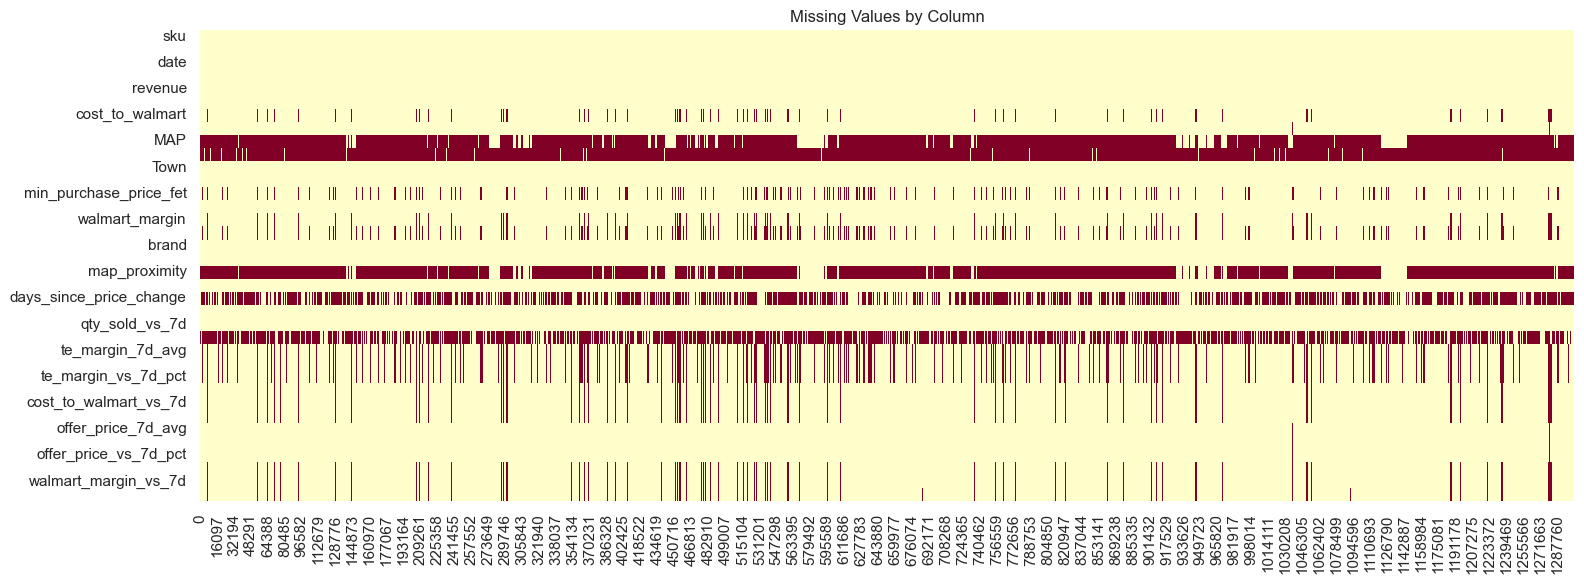

In [25]:
# Missing values heatmap
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(df.isnull().T, cbar=False, cmap="YlOrRd", ax=ax)
ax.set_title("Missing Values by Column")
plt.tight_layout()
plt.show()

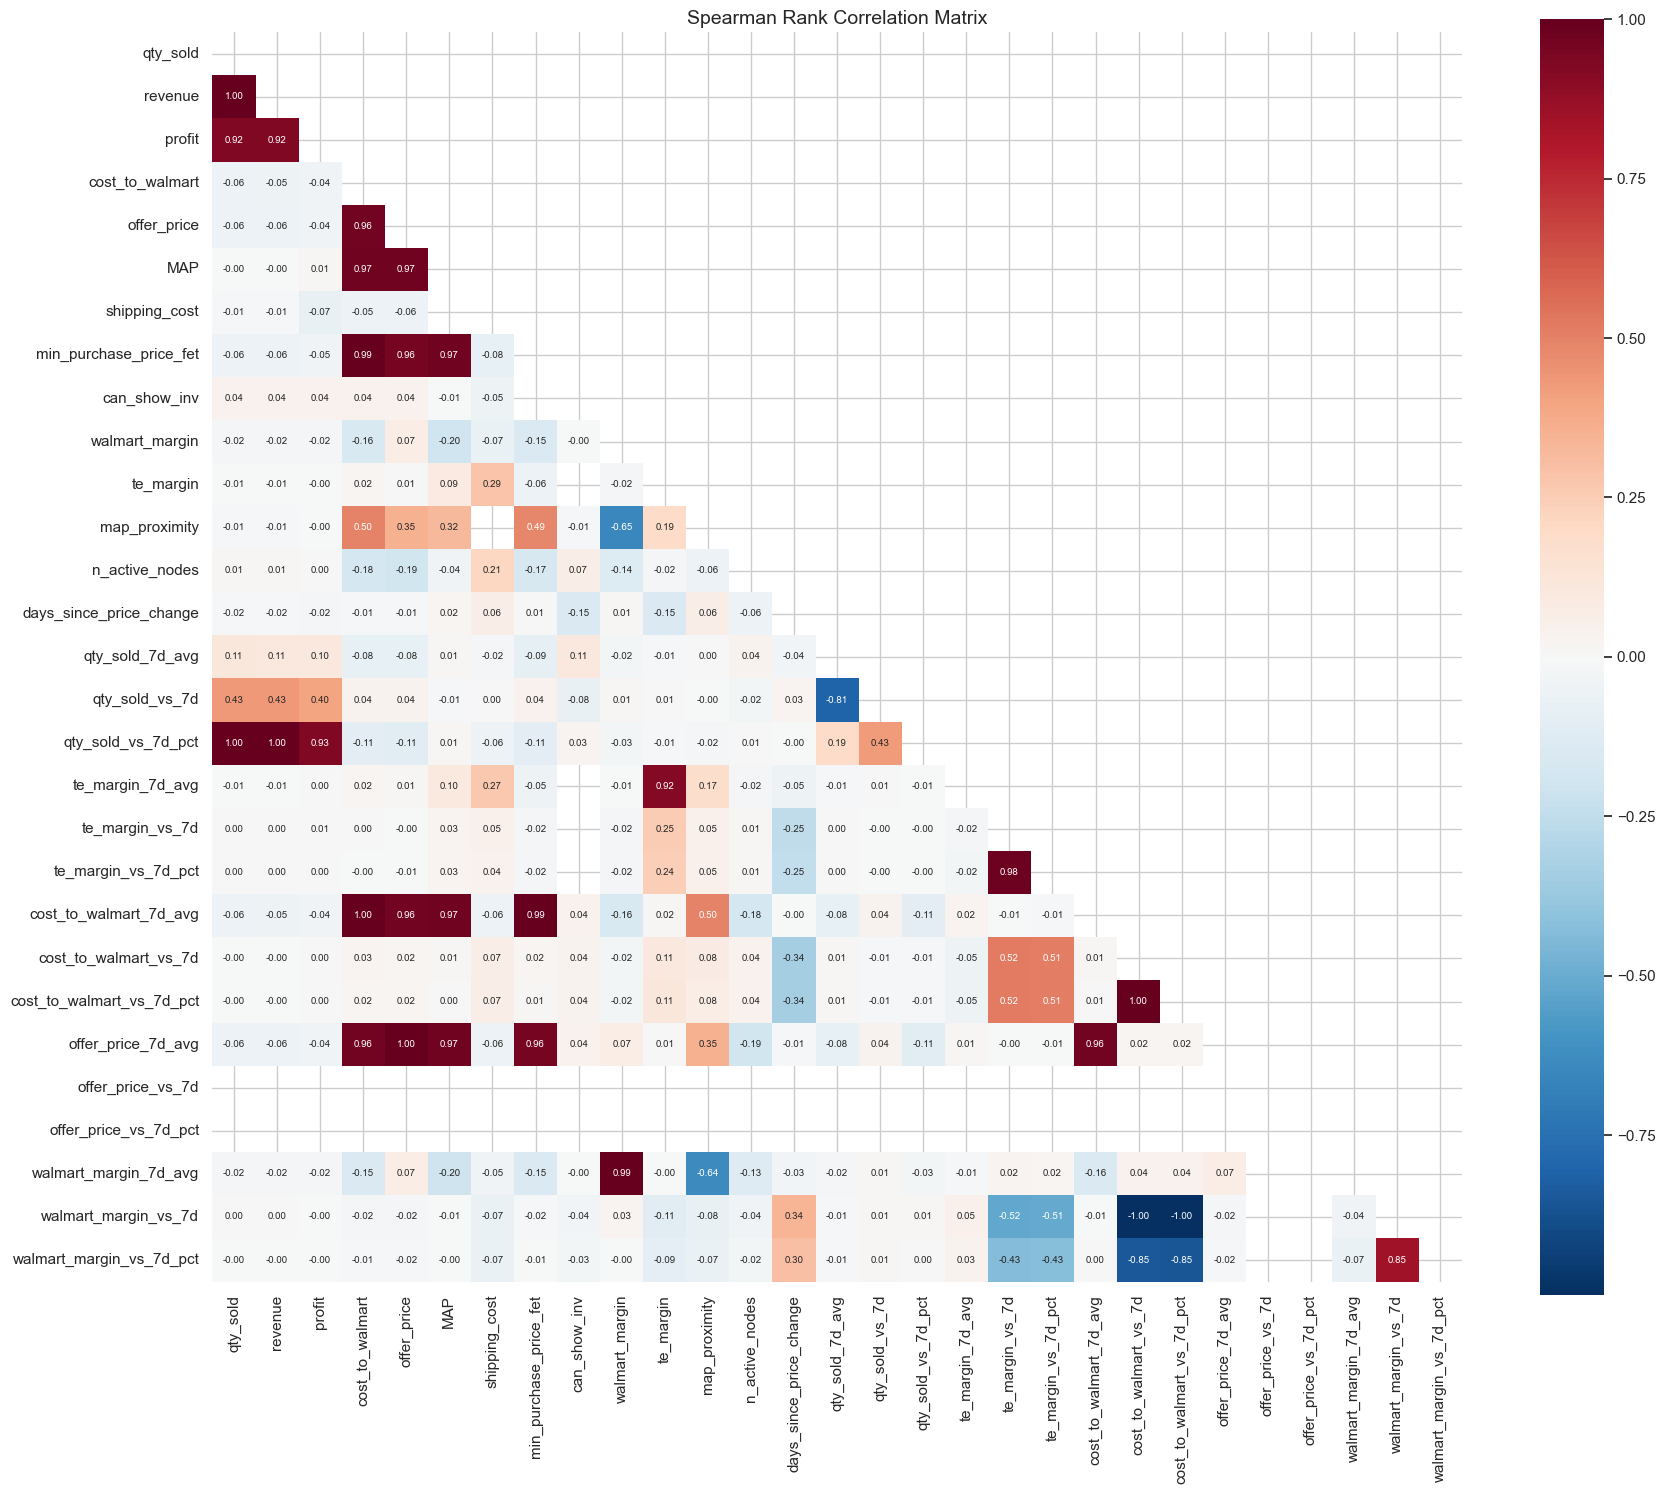

In [26]:
# Spearman correlation matrix (full numeric columns)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID-like columns
numeric_cols = [c for c in numeric_cols if c not in ["day_of_week"]]

corr_matrix = df[numeric_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, ax=ax,
    annot_kws={"size": 7}, square=True,
)
ax.set_title("Spearman Rank Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

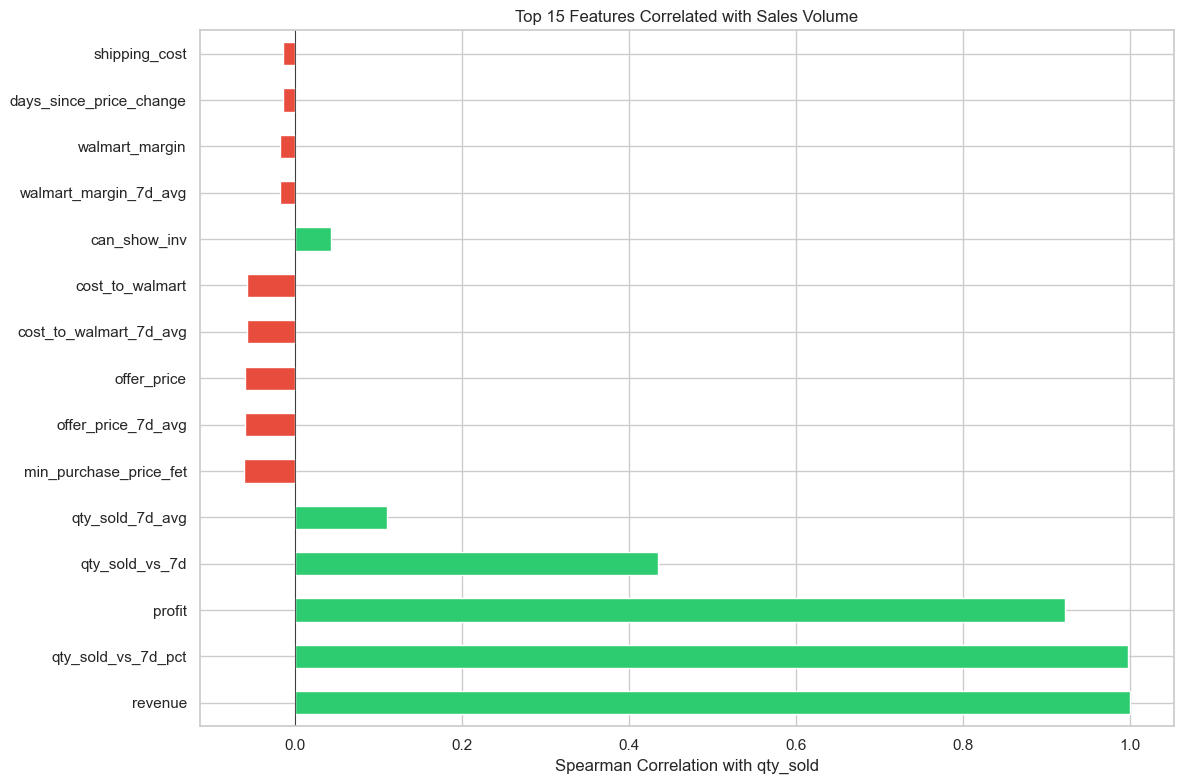


Top 15 correlations with qty_sold:
revenue                    0.999813
qty_sold_vs_7d_pct         0.998071
profit                     0.922758
qty_sold_vs_7d             0.434462
qty_sold_7d_avg            0.109679
min_purchase_price_fet    -0.060995
offer_price_7d_avg        -0.059950
offer_price               -0.059950
cost_to_walmart_7d_avg    -0.057358
cost_to_walmart           -0.057298
can_show_inv               0.042408
walmart_margin_7d_avg     -0.018333
walmart_margin            -0.018196
days_since_price_change   -0.015186
shipping_cost             -0.014223


In [27]:
# Top correlations with qty_sold
target_corrs = (
    corr_matrix["qty_sold"]
    .drop("qty_sold")
    .dropna()
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corrs.head(15)]
target_corrs.head(15).plot.barh(ax=ax, color=colors)
ax.set_xlabel("Spearman Correlation with qty_sold")
ax.set_title("Top 15 Features Correlated with Sales Volume")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop 15 correlations with qty_sold:")
print(target_corrs.head(15).to_string())

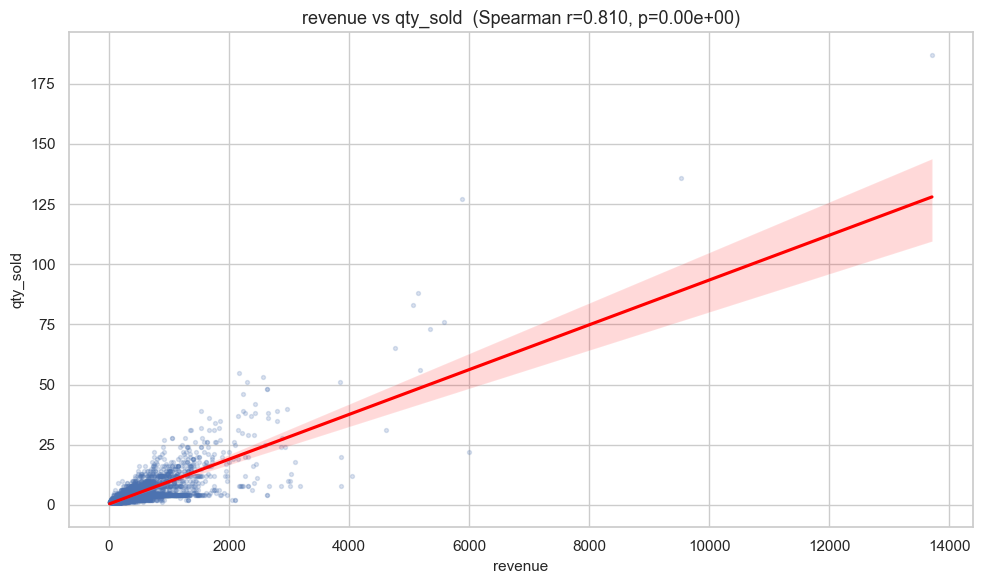

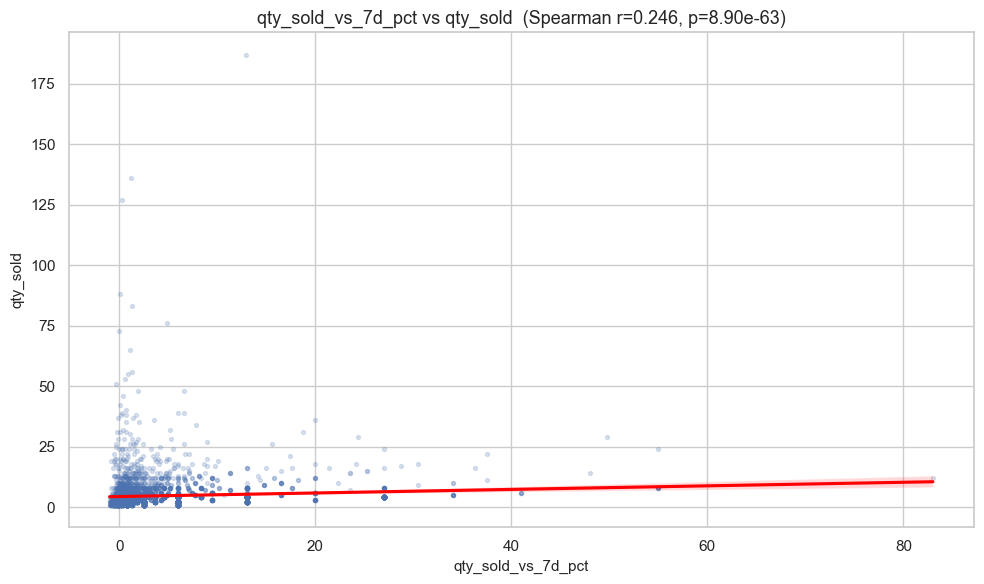

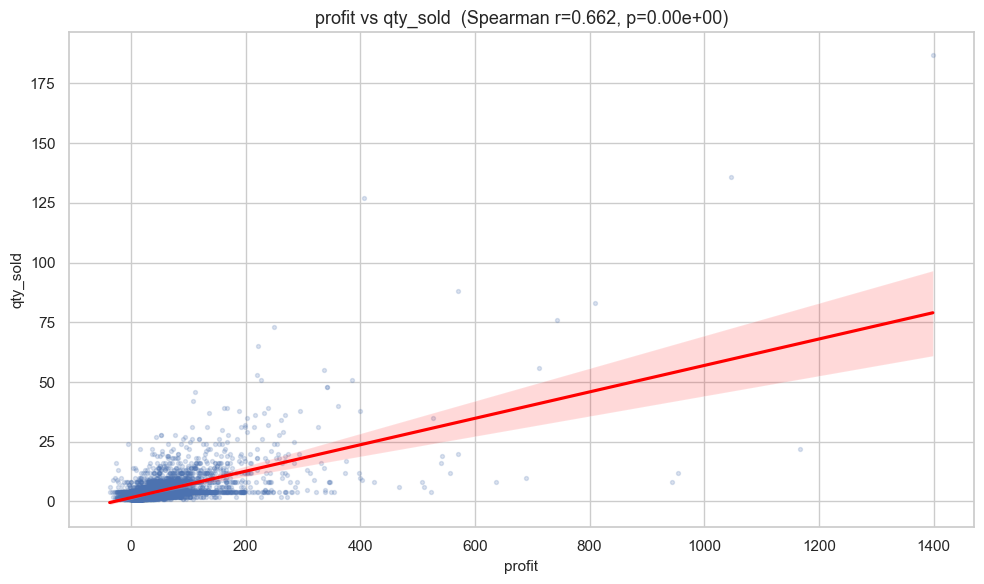

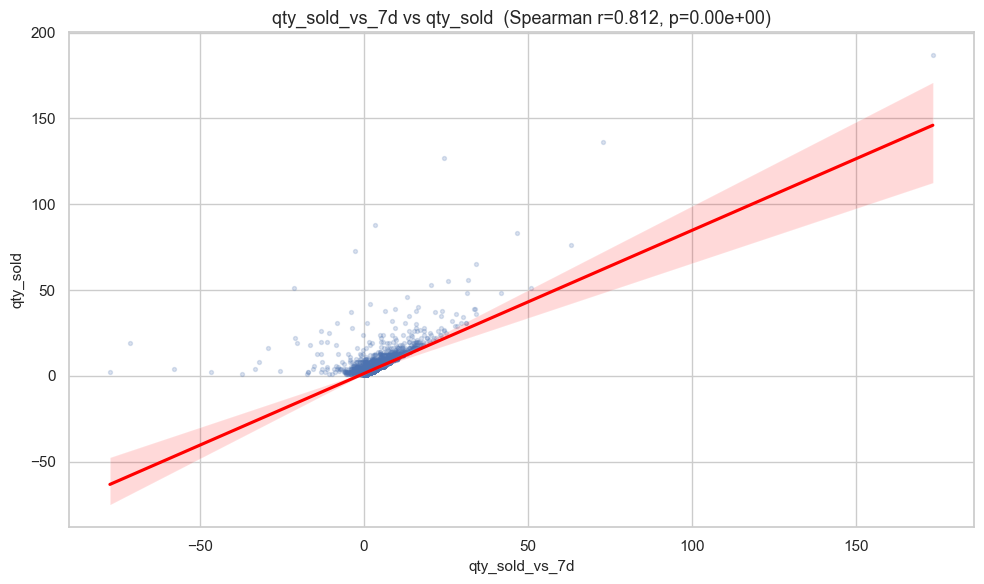

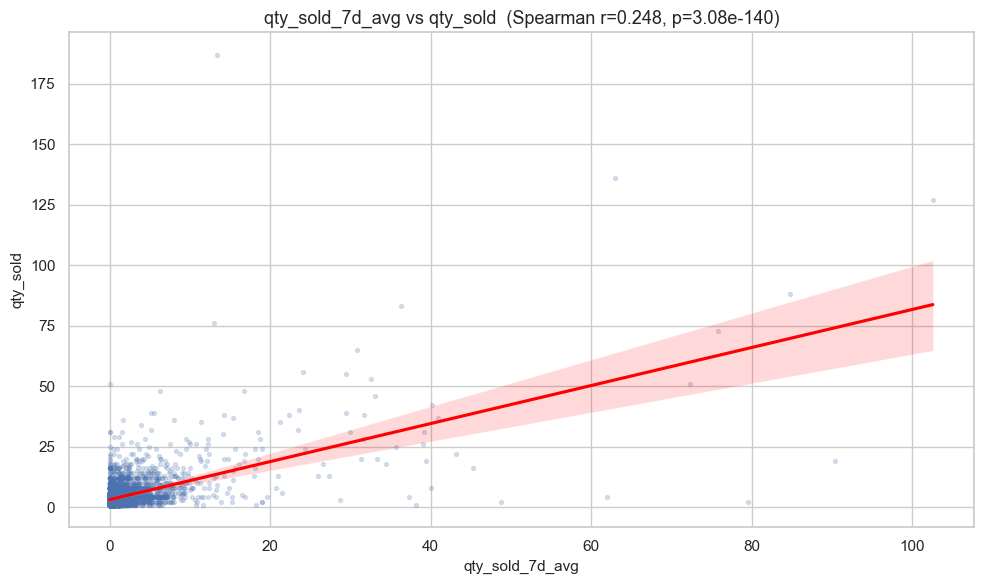

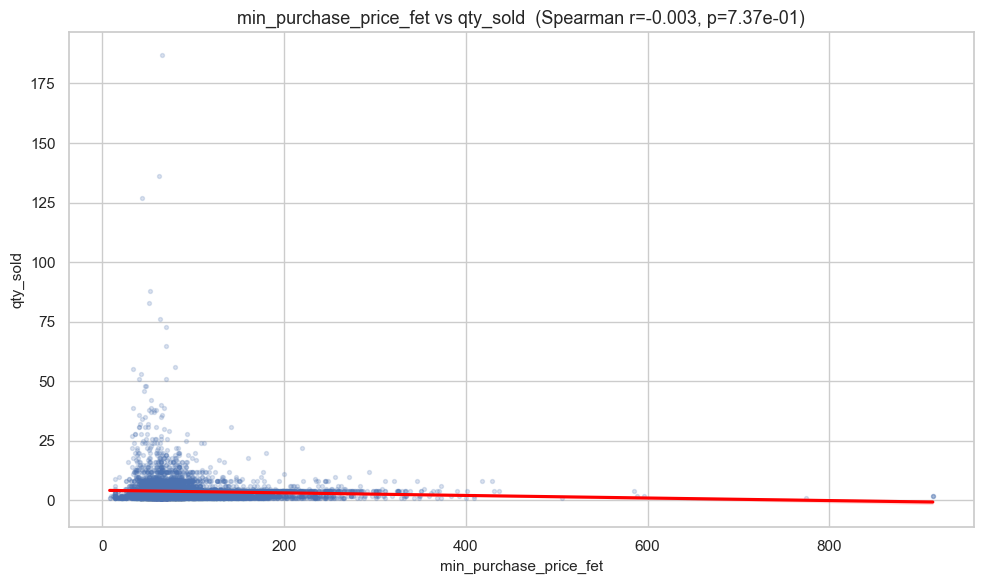

In [28]:
# Scatter plots for top 6 correlated features (individual figures for clarity)
top_features = target_corrs.head(6).index.tolist()

# Sample for performance
df_nonzero = df[df["qty_sold"] > 0]
df_sample = df_nonzero.sample(n=min(10000, len(df_nonzero)), random_state=42)

for col in top_features:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(
        data=df_sample, x=col, y="qty_sold", ax=ax,
        scatter_kws={"alpha": 0.2, "s": 8}, line_kws={"color": "red"},
    )
    valid = df_sample[[col, "qty_sold"]].dropna()
    r, p = stats.spearmanr(valid[col], valid["qty_sold"])
    ax.set_title(f"{col} vs qty_sold  (Spearman r={r:.3f}, p={p:.2e})", fontsize=13)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("qty_sold", fontsize=11)
    plt.tight_layout()
    plt.show()


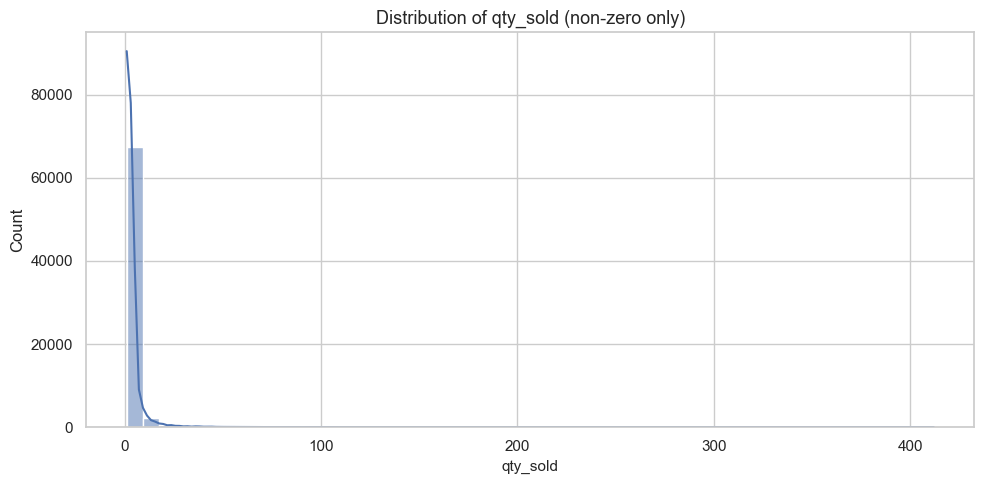

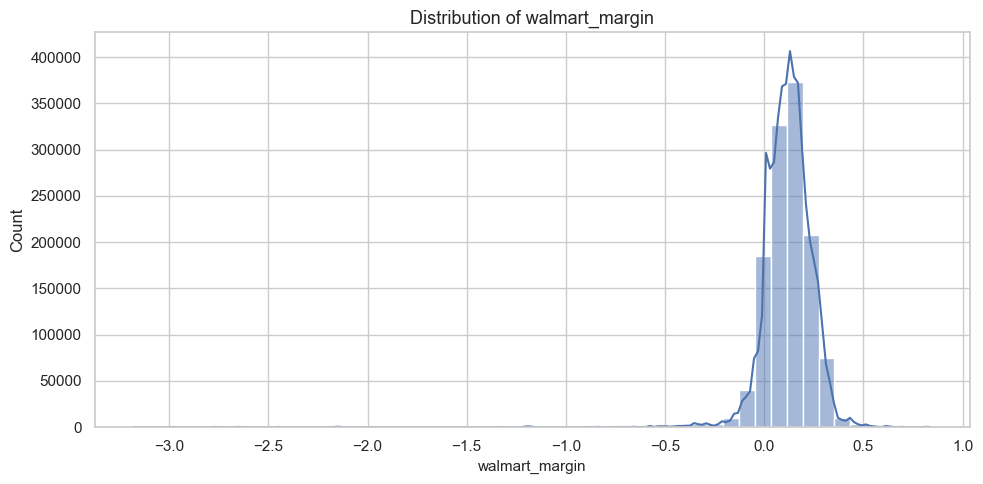

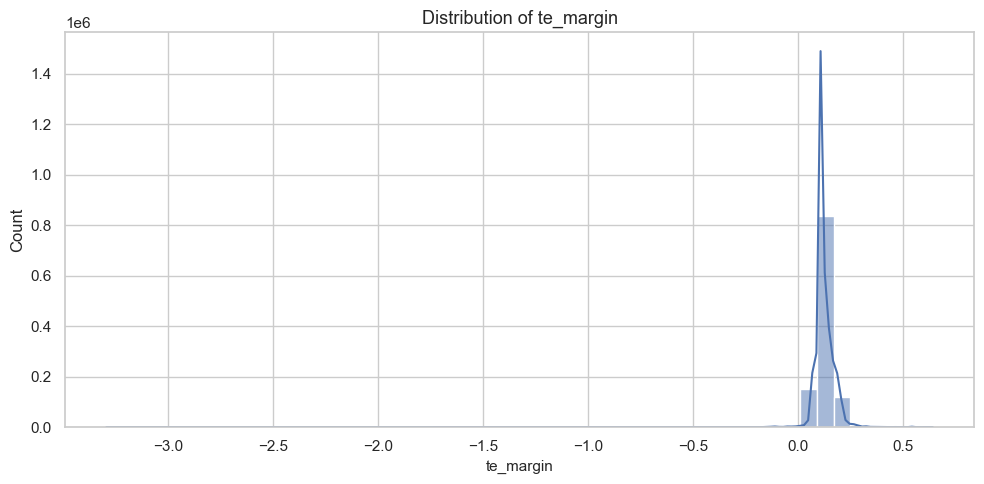

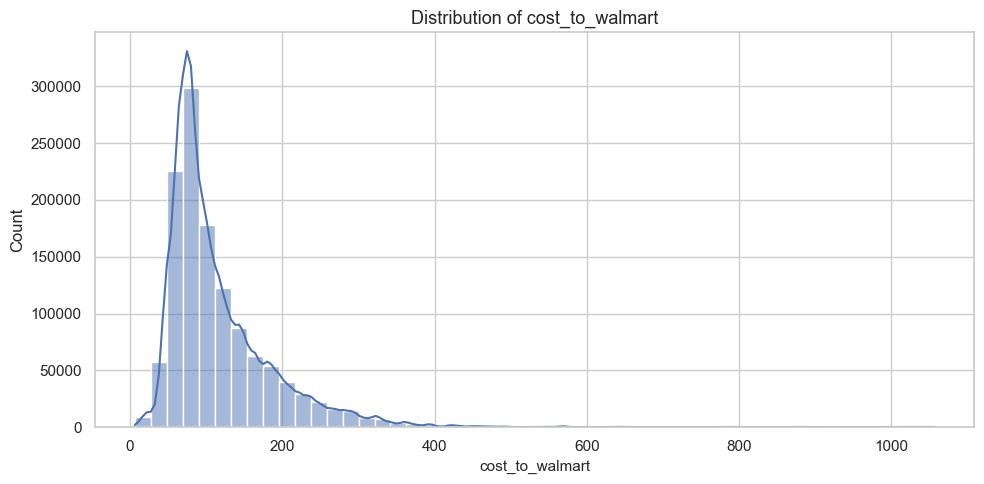

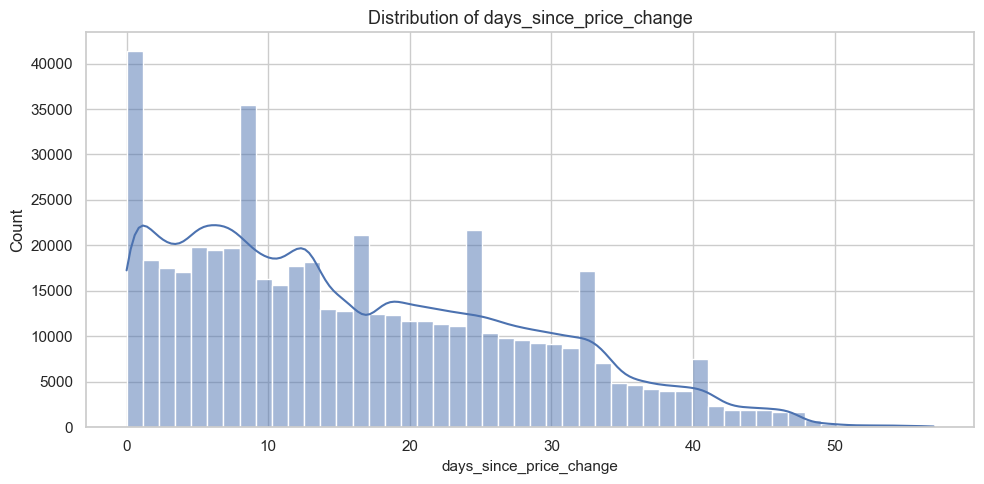

In [29]:
# Distribution plots for key variables (individual figures)
dist_cols = ["qty_sold", "walmart_margin", "te_margin", "cost_to_walmart", "days_since_price_change"]
dist_cols = [c for c in dist_cols if c in df.columns]

for col in dist_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    data = df[col].dropna()
    if col == "qty_sold":
        data = data[data > 0]  # Skip zeros for visibility
        ax.set_title(f"Distribution of {col} (non-zero only)", fontsize=13)
    else:
        ax.set_title(f"Distribution of {col}", fontsize=13)
    sns.histplot(data, ax=ax, bins=50, kde=True)
    ax.set_xlabel(col, fontsize=11)
    plt.tight_layout()
    plt.show()


## 12. Statistical Tests

In [30]:
# Test 1: Price change impact on sales
# Compare qty_sold on days with a recent price change (<=3 days) vs no change (>7 days)
recent_change = df[df["days_since_price_change"] <= 3]["qty_sold"]
no_change = df[df["days_since_price_change"] > 7]["qty_sold"]

if len(recent_change) > 0 and len(no_change) > 0:
    stat, pval = stats.mannwhitneyu(recent_change, no_change, alternative="two-sided")
    print("=== Price Change Impact on Sales ===")
    print(f"Recent change (<=3 days): n={len(recent_change):,}, mean={recent_change.mean():.3f}, median={recent_change.median():.1f}")
    print(f"No recent change (>7 days): n={len(no_change):,}, mean={no_change.mean():.3f}, median={no_change.median():.1f}")
    print(f"Mann-Whitney U stat={stat:.0f}, p-value={pval:.4e}")
    print(f"Significant at 5%: {'Yes' if pval < 0.05 else 'No'}")
else:
    print("Insufficient data for price change analysis")

=== Price Change Impact on Sales ===
Recent change (<=3 days): n=77,300, mean=0.198, median=0.0
No recent change (>7 days): n=366,370, mean=0.176, median=0.0
Mann-Whitney U stat=14268241692, p-value=7.1426e-19
Significant at 5%: Yes


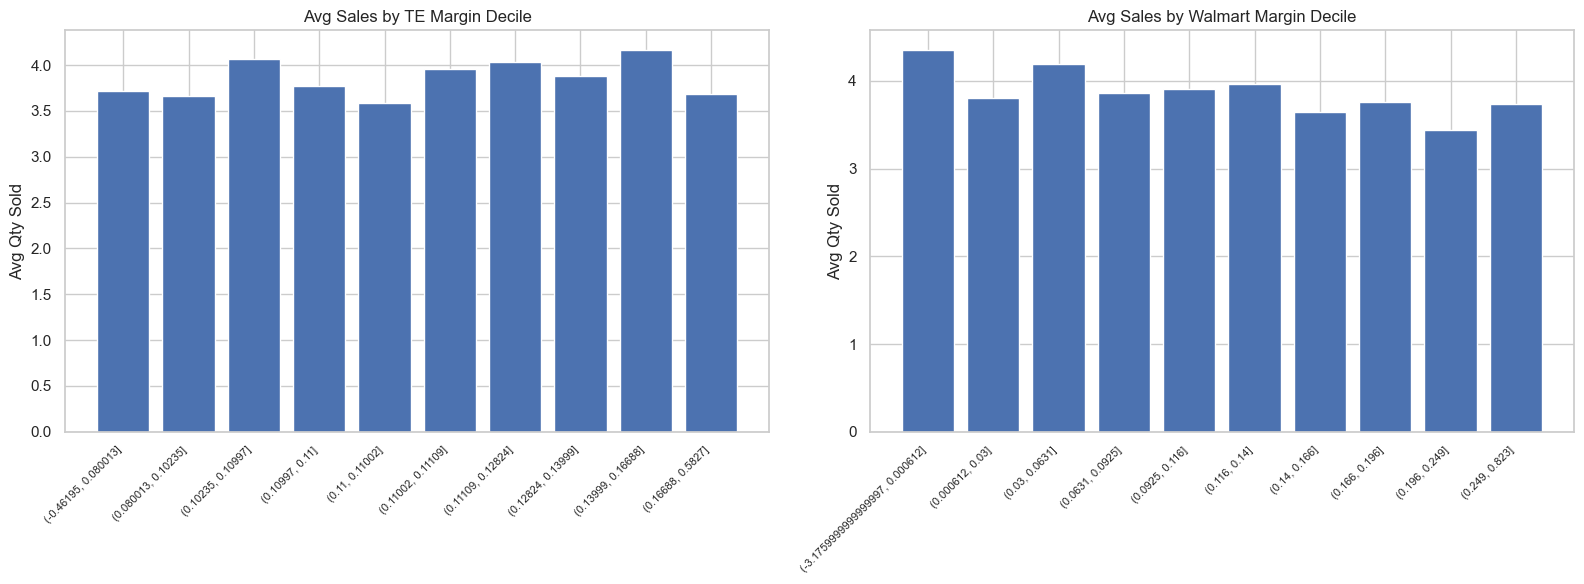

In [31]:
# Test 2: Margin level vs. revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, label in zip(axes, ["te_margin", "walmart_margin"], ["TE Margin", "Walmart Margin"]):
    df_valid = df[df[col].notna() & (df["qty_sold"] > 0)].copy()
    if len(df_valid) > 100:
        df_valid["margin_bin"] = pd.qcut(df_valid[col], 10, duplicates="drop")
        margin_revenue = (
            df_valid.groupby("margin_bin", observed=True)
            .agg(avg_qty=("qty_sold", "mean"), total_qty=("qty_sold", "sum"), count=("qty_sold", "count"))
            .reset_index()
        )
        margin_revenue["margin_bin"] = margin_revenue["margin_bin"].astype(str)
        ax.bar(range(len(margin_revenue)), margin_revenue["avg_qty"])
        ax.set_xticks(range(len(margin_revenue)))
        ax.set_xticklabels(margin_revenue["margin_bin"], rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("Avg Qty Sold")
        ax.set_title(f"Avg Sales by {label} Decile")
    else:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [32]:
# Test 3: Inventory availability vs sales
inv_yes = df[df["can_show_inv"] == 1]["qty_sold"]
inv_no = df[df["can_show_inv"] == 0]["qty_sold"]

print("=== Inventory Availability vs Sales ===")
print(f"With inventory:    n={len(inv_yes):,}, mean={inv_yes.mean():.3f}, median={inv_yes.median():.1f}")
print(f"Without inventory: n={len(inv_no):,}, mean={inv_no.mean():.3f}, median={inv_no.median():.1f}")

if len(inv_yes) > 0 and len(inv_no) > 0:
    stat, pval = stats.mannwhitneyu(inv_yes, inv_no, alternative="two-sided")
    print(f"Mann-Whitney U stat={stat:.0f}, p-value={pval:.4e}")
    print(f"Significant at 5%: {'Yes' if pval < 0.05 else 'No'}")

=== Inventory Availability vs Sales ===
With inventory:    n=1,152,024, mean=0.225, median=0.0
Without inventory: n=151,806, mean=0.115, median=0.0
Mann-Whitney U stat=90061583420, p-value=0.0000e+00
Significant at 5%: Yes


In [33]:
# Test 4: OLS regression
import statsmodels.api as sm

feature_cols = [
    "cost_to_walmart", "offer_price", "walmart_margin", "te_margin",
    "can_show_inv", "shipping_cost", "n_active_nodes", "day_of_week",
    "days_since_price_change",
]
feature_cols = [c for c in feature_cols if c in df.columns]

df_reg = df[feature_cols + ["qty_sold"]].dropna()

if len(df_reg) > 100:
    X = sm.add_constant(df_reg[feature_cols])
    y = df_reg["qty_sold"]
    model = sm.OLS(y, X).fit()
    print(model.summary())
else:
    print("Insufficient data for OLS regression")

                            OLS Regression Results                            
Dep. Variable:               qty_sold   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     10.88
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           2.13e-15
Time:                        15:58:20   Log-Likelihood:                -17136.
No. Observations:               12690   AIC:                         3.429e+04
Df Residuals:                   12681   BIC:                         3.436e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
cost_to_walmart           

In [34]:
# Also run with log-transformed qty_sold (to handle zero-inflation)
df_reg_log = df_reg[df_reg["qty_sold"] > 0].copy()
if len(df_reg_log) > 100:
    X_log = sm.add_constant(df_reg_log[feature_cols])
    y_log = np.log1p(df_reg_log["qty_sold"])
    model_log = sm.OLS(y_log, X_log).fit()
    print("=== OLS with log(1 + qty_sold), non-zero sales only ===")
    print(model_log.summary())
else:
    print("Insufficient non-zero sales data for log OLS")

=== OLS with log(1 + qty_sold), non-zero sales only ===
                            OLS Regression Results                            
Dep. Variable:               qty_sold   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     3.377
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000816
Time:                        15:58:21   Log-Likelihood:                -409.12
No. Observations:                 741   AIC:                             836.2
Df Residuals:                     732   BIC:                             877.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

## 13. Geographic & Brand Analysis

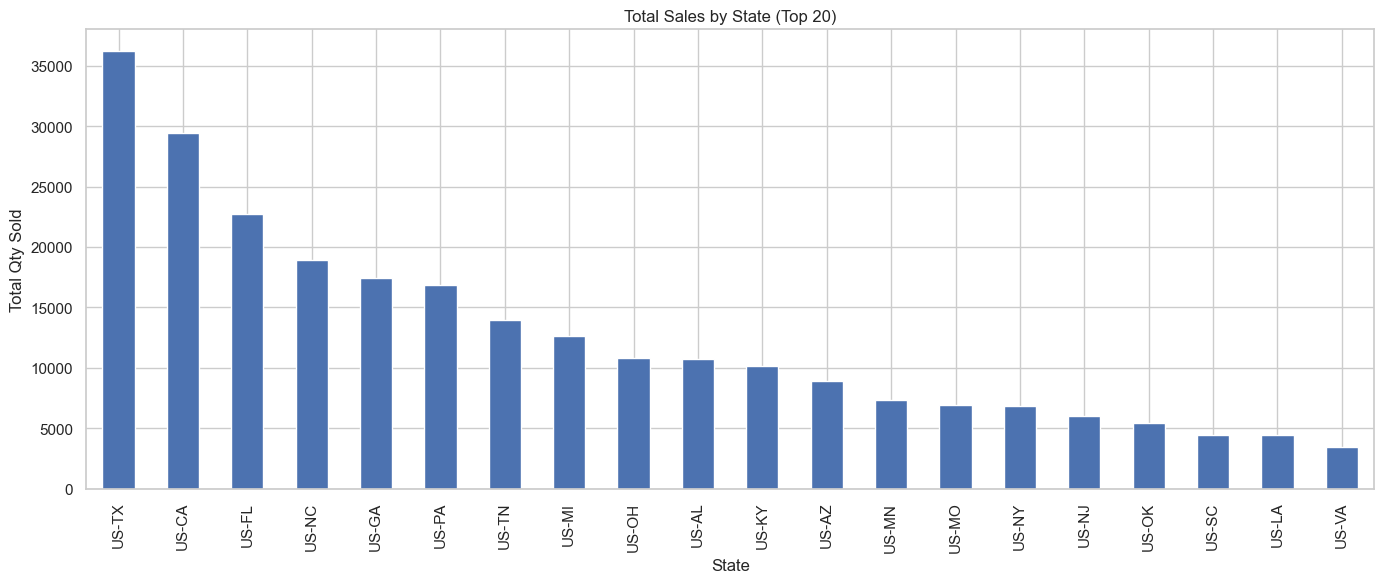

,total_qty,avg_wm_margin,avg_te_margin,n_nodes
State,,,,
US-TX,36207.0,0.122876,0.118208,111
US-CA,29417.0,0.114418,0.120090,110
US-FL,22695.0,0.119134,0.119774,90
US-NC,18939.0,0.097880,0.122175,59
US-GA,17428.0,0.115123,0.115158,52
US-PA,16886.0,0.139184,0.120621,37
US-TN,13923.0,0.131620,0.120008,44
US-MI,12593.0,0.142123,0.127995,34
US-OH,10812.0,0.126151,0.120015,46


In [35]:
# Sales by state
state_sales = (
    df.groupby("State")
    .agg(
        total_qty=("qty_sold", "sum"),
        avg_wm_margin=("walmart_margin", "mean"),
        avg_te_margin=("te_margin", "mean"),
        n_nodes=("node", "nunique"),
    )
    .sort_values("total_qty", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(14, 6))
state_sales["total_qty"].plot.bar(ax=ax)
ax.set_title("Total Sales by State (Top 20)")
ax.set_ylabel("Total Qty Sold")
ax.set_xlabel("State")
plt.tight_layout()
plt.show()

state_sales

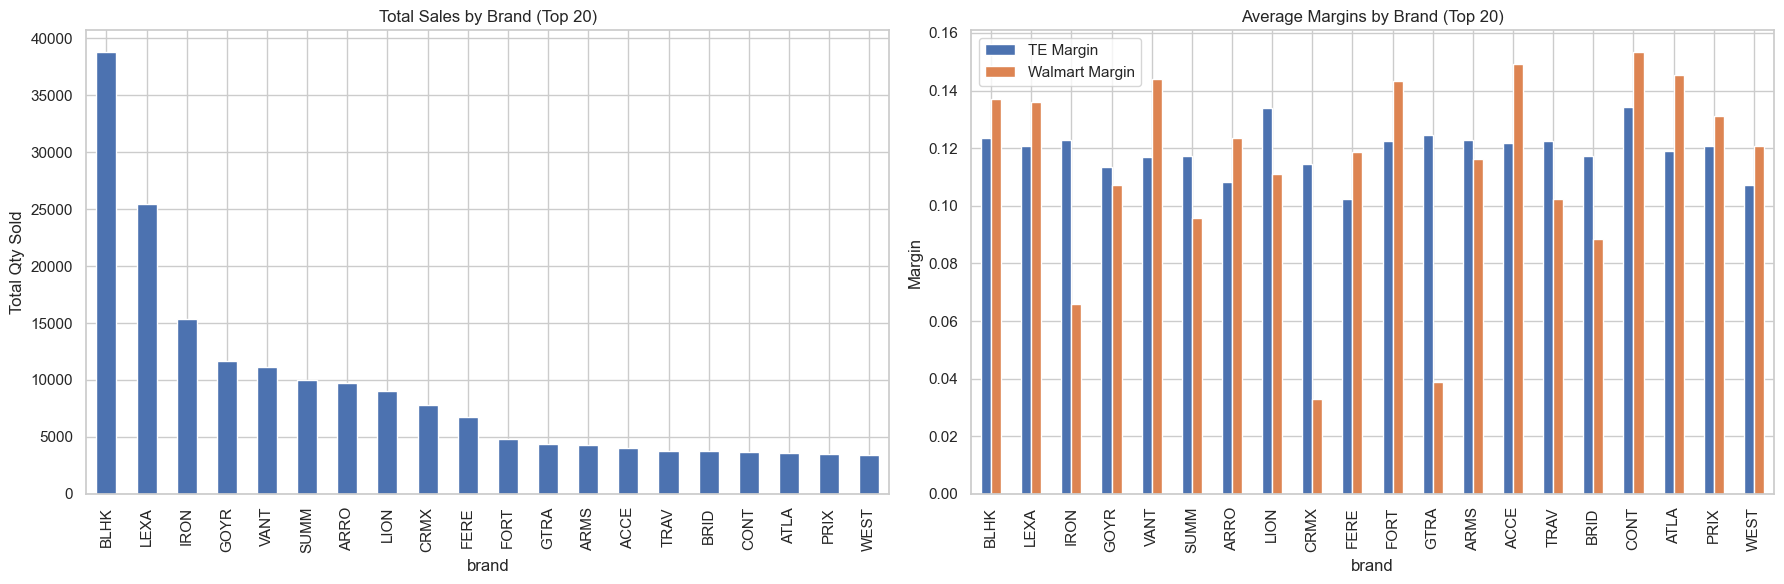

,total_qty,total_revenue,avg_te_margin,avg_wm_margin,n_skus,n_nodes
brand,,,,,,
BLHK,38748.0,3371910.02,0.123674,0.136912,236,61
LEXA,25490.0,2150428.17,0.120768,0.135877,286,97
IRON,15360.0,1193522.02,0.122974,0.066000,162,352
GOYR,11640.0,1945585.19,0.113533,0.107366,276,471
VANT,11140.0,775336.20,0.117028,0.143934,61,310
SUMM,10024.0,912129.88,0.117259,0.095887,152,25
ARRO,9743.0,745008.85,0.108317,0.123605,189,66
LION,8994.0,628962.32,0.134054,0.111109,156,71
CRMX,7791.0,532204.21,0.114543,0.032939,48,17


In [36]:
# Brand-level analysis
brand_analysis = (
    df.groupby("brand")
    .agg(
        total_qty=("qty_sold", "sum"),
        total_revenue=("revenue", "sum"),
        avg_te_margin=("te_margin", "mean"),
        avg_wm_margin=("walmart_margin", "mean"),
        n_skus=("sku", "nunique"),
        n_nodes=("node", "nunique"),
    )
    .sort_values("total_qty", ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

brand_analysis["total_qty"].plot.bar(ax=axes[0])
axes[0].set_title("Total Sales by Brand (Top 20)")
axes[0].set_ylabel("Total Qty Sold")

brand_analysis[["avg_te_margin", "avg_wm_margin"]].plot.bar(ax=axes[1])
axes[1].set_title("Average Margins by Brand (Top 20)")
axes[1].set_ylabel("Margin")
axes[1].legend(["TE Margin", "Walmart Margin"])

plt.tight_layout()
plt.show()

brand_analysis

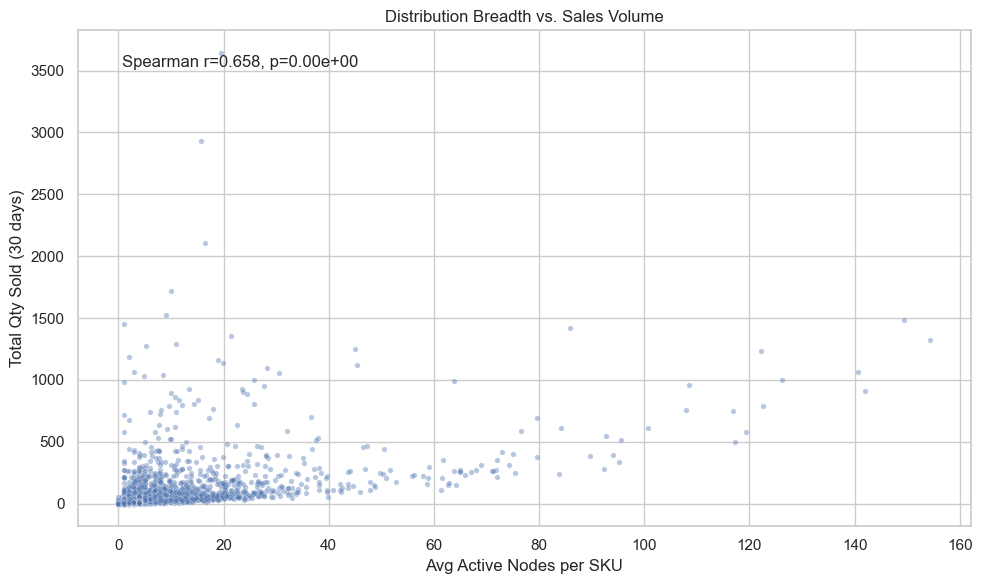

In [37]:
# Node distribution breadth vs sales
breadth = (
    df.groupby("sku")
    .agg(
        avg_active_nodes=("n_active_nodes", "mean"),
        total_qty=("qty_sold", "sum"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=breadth, x="avg_active_nodes", y="total_qty", alpha=0.4, s=15, ax=ax)
ax.set_xlabel("Avg Active Nodes per SKU")
ax.set_ylabel("Total Qty Sold (30 days)")
ax.set_title("Distribution Breadth vs. Sales Volume")

r, p = stats.spearmanr(breadth["avg_active_nodes"], breadth["total_qty"])
ax.text(0.05, 0.95, f"Spearman r={r:.3f}, p={p:.2e}", transform=ax.transAxes, va="top")

plt.tight_layout()
plt.show()

## 14. Summary & Cleanup

### Key Findings

*(See Section 28 — Executive Summary below for comprehensive, data-driven findings populated after extended analysis)*

In [ ]:
# Save the assembled dataset for future use
project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
output_dir = os.path.join(project_root, "outputs")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"correlation_dataset_{END_DATE}.parquet")
try:
    df.to_parquet(output_path, index=False)
    print(f"Dataset saved to {output_path}")
except Exception as e:
    output_path = output_path.replace(".parquet", ".csv")
    df.to_csv(output_path, index=False)
    print(f"Parquet failed ({e}), saved as CSV: {output_path}")

print(f"Shape: {df.shape}")
print("Data assembly complete. Proceeding to extended analysis...")

## 15. Extended Setup & Feature Engineering

In [ ]:
# Load tests tracker and merge A/B test assignments onto df
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

tracker_path = TRACKER_PATH
# Fall back to local copy if H: drive not available
import os
if not os.path.exists(tracker_path):
    tracker_path = os.path.join(project_root, "outputs", "Final node level costs tracker.csv")
    print(f"H: drive tracker not found, using local copy: {tracker_path}")

df_tracker = pd.read_csv(tracker_path, low_memory=False)
print(f"Tracker rows: {len(df_tracker):,}")

# Keep latest entry per SKU-Node
df_tracker["SKU_Node"] = df_tracker["Product Code"].astype(str) + "-" + df_tracker["Identifier"].astype(str)
df_tracker = df_tracker.sort_values("Start date").drop_duplicates("SKU_Node", keep="last")

# Create SKU_Node key in df
df["SKU_Node"] = df["sku"].astype(str) + "-" + df["node"].astype(str)

# Merge test assignments
tracker_cols = ["SKU_Node", "Final target", "Sub-group", "Start date", "Final price category"]
df = df.merge(df_tracker[tracker_cols], on="SKU_Node", how="left")

print(f"Matched to tracker: {df['Final target'].notna().sum():,} / {len(df):,} rows")
print(f"\nFinal target distribution in analysis data:")
print(df["Final target"].value_counts())

In [ ]:
# Feature engineering for extended analysis
start_dt = pd.Timestamp(START_DATE)

# Binary sale indicator
df["has_sale"] = (df["qty_sold"] > 0).astype(int)

# Log-transformed quantity
df["log_qty"] = np.log1p(df["qty_sold"])

# Price tier (quartiles within each brand, handling NaN offer_price)
df["price_tier"] = "Unknown"
for brand, grp in df[df["offer_price"].notna()].groupby("brand"):
    try:
        tiers = pd.qcut(grp["offer_price"], q=4, labels=["Budget", "Mid-Low", "Mid-High", "Premium"], duplicates="drop")
        df.loc[tiers.index, "price_tier"] = tiers.astype(str)
    except ValueError:
        pass  # Skip brands with insufficient price variation

# Week number within analysis window
df["week_number"] = ((df["date"] - start_dt).dt.days // 7).clip(lower=0)

# Price percent change vs 7d avg
df["price_pct_change"] = df["offer_price_vs_7d_pct"]

print(f"has_sale distribution: {df['has_sale'].value_counts().to_dict()}")
print(f"price_tier distribution:\n{df['price_tier'].value_counts()}")
print(f"Weeks in analysis: {df['week_number'].nunique()}")

## 16. Two-Stage Model — Stage 1: Logistic Regression for P(sale > 0)

The dataset has 75%+ zero sales. A single model conflates "what drives ANY sale" with "what drives VOLUME."
Stage 1 models the probability of any sale occurring using logistic regression.

In [ ]:
# Stage 1: Logistic regression for P(sale > 0)
import statsmodels.api as sm

feature_cols_logit = [
    "can_show_inv", "cost_to_walmart", "offer_price",
    "walmart_margin", "te_margin", "n_active_nodes",
    "days_since_price_change", "day_of_week",
]

df_logit = df[feature_cols_logit + ["has_sale"]].dropna()
# Replace inf values with NaN then drop
df_logit = df_logit.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Logit sample size: {len(df_logit):,} (dropped {len(df) - len(df_logit):,} rows with NaN/inf)")

# Check for multicollinearity and drop highly correlated features
corr = df_logit[feature_cols_logit].corr().abs()
# Drop offer_price if highly correlated with cost_to_walmart (both are price measures)
if corr.loc["cost_to_walmart", "offer_price"] > 0.9:
    feature_cols_logit = [c for c in feature_cols_logit if c != "offer_price"]
    print("Dropped offer_price (corr > 0.9 with cost_to_walmart) to avoid singularity")

# Standardize features for comparable coefficients
logit_means = df_logit[feature_cols_logit].mean()
logit_stds = df_logit[feature_cols_logit].std()
# Avoid division by zero for constant columns
logit_stds = logit_stds.replace(0, 1)
X_logit = (df_logit[feature_cols_logit] - logit_means) / logit_stds
X_logit = sm.add_constant(X_logit)
y_logit = df_logit["has_sale"]

# Fit logistic regression (use bfgs method which is more robust to near-singularity)
logit_model = sm.Logit(y_logit, X_logit).fit(disp=0, maxiter=200, method="bfgs")
print(logit_model.summary())

In [ ]:
# Odds ratios with 95% CI
odds_ratios = np.exp(logit_model.params)
ci = np.exp(logit_model.conf_int())
ci.columns = ["OR_lower", "OR_upper"]

or_df = pd.DataFrame({
    "Odds Ratio": odds_ratios,
    "OR_lower": ci["OR_lower"],
    "OR_upper": ci["OR_upper"],
    "p-value": logit_model.pvalues,
}).drop("const", errors="ignore")

or_df = or_df.sort_values("Odds Ratio", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(or_df))
ax.barh(y_pos, or_df["Odds Ratio"] - 1, left=1, color=["#2ecc71" if v > 1 else "#e74c3c" for v in or_df["Odds Ratio"]], alpha=0.7)
ax.errorbar(or_df["Odds Ratio"], y_pos, xerr=[or_df["Odds Ratio"] - or_df["OR_lower"], or_df["OR_upper"] - or_df["Odds Ratio"]], fmt="none", color="black", capsize=3)
ax.axvline(x=1, color="black", linestyle="--", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(or_df.index)
ax.set_xlabel("Odds Ratio (standardized features)")
ax.set_title("Stage 1 Logistic Regression — Odds Ratios for P(sale > 0)")
plt.tight_layout()
plt.show()

print("\nOdds Ratios Table:")
print(or_df.to_string(float_format="%.4f"))

In [ ]:
# Marginal effects at means (may fail if Hessian inversion was problematic)
try:
    margeff = logit_model.get_margeff(at="mean")
    print("Marginal Effects at Means:")
    print(margeff.summary())
except Exception as e:
    print(f"Marginal effects not available ({e})")
    print("Showing coefficient-based interpretation instead:")
    for feat in feature_cols_logit:
        coef = logit_model.params.get(feat, np.nan)
        print(f"  {feat}: coeff={coef:.4f}, direction={'positive' if coef > 0 else 'negative'}")

# Manual AUC-ROC calculation (no sklearn needed)
y_true = y_logit.values
y_pred = logit_model.predict(X_logit)

# Sort by predicted probability descending
sorted_idx = np.argsort(-y_pred)
y_sorted = y_true[sorted_idx]

# Compute ROC curve points
tpr_list, fpr_list = [0], [0]
tp, fp = 0, 0
total_pos = y_sorted.sum()
total_neg = len(y_sorted) - total_pos

for i in range(len(y_sorted)):
    if y_sorted[i] == 1:
        tp += 1
    else:
        fp += 1
    if i % max(1, len(y_sorted) // 500) == 0 or i == len(y_sorted) - 1:
        tpr_list.append(tp / total_pos)
        fpr_list.append(fp / total_neg)

# AUC via trapezoidal rule (np.trapezoid for NumPy >= 2.0)
_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))
auc_roc = _trapz(tpr_list, fpr_list)
print(f"\nAUC-ROC: {auc_roc:.4f}")

# Classification metrics at 0.5 threshold
y_class = (y_pred >= 0.5).astype(int)
accuracy = (y_class == y_true).mean()
tp_count = ((y_class == 1) & (y_true == 1)).sum()
fp_count = ((y_class == 1) & (y_true == 0)).sum()
fn_count = ((y_class == 0) & (y_true == 1)).sum()
precision = tp_count / max(tp_count + fp_count, 1)
recall = tp_count / max(tp_count + fn_count, 1)
print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

# Plot ROC
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_list, tpr_list, color="#3498db", linewidth=2, label=f"ROC (AUC = {auc_roc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Stage 1 Logistic — ROC Curve")
ax.legend()
plt.tight_layout()
plt.show()

## 17. Two-Stage Model — Stage 2: Negative Binomial for qty | sale > 0

Among SKU-Node-Dates that had at least one sale, model the quantity using a count model
that handles overdispersion (variance >> mean).

In [ ]:
# Test for overdispersion: Poisson deviance / df
from statsmodels.discrete.discrete_model import Poisson, NegativeBinomial

feature_cols_count = [
    "can_show_inv", "cost_to_walmart", "offer_price",
    "walmart_margin", "te_margin", "n_active_nodes",
    "days_since_price_change", "day_of_week",
]

df_pos = df[df["qty_sold"] > 0][feature_cols_count + ["qty_sold"]].dropna()
df_pos = df_pos.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Positive-sales sample: {len(df_pos):,} rows")
print(f"qty_sold stats: mean={df_pos['qty_sold'].mean():.2f}, var={df_pos['qty_sold'].var():.2f}, max={df_pos['qty_sold'].max():.0f}")

X_count = sm.add_constant(df_pos[feature_cols_count])
y_count = df_pos["qty_sold"]

# Fit Poisson first
poisson_model = Poisson(y_count, X_count).fit(disp=0, maxiter=100)
# Overdispersion check: compare mean and variance of response
# (Poisson assumes mean == variance; ratio >> 1 means overdispersion)
overdispersion = df_pos["qty_sold"].var() / df_pos["qty_sold"].mean()
print(f"\nVariance/Mean ratio = {overdispersion:.2f} (>1 indicates overdispersion)")
print(f"Poisson AIC: {poisson_model.aic:.1f}")

In [ ]:
# Fit Negative Binomial (NB2)
try:
    negbin_model = NegativeBinomial(y_count, X_count, loglike_method="nb2").fit(disp=0, maxiter=200)
    print(negbin_model.summary())
    print(f"\nNegBin AIC: {negbin_model.aic:.1f}")

    # Incidence Rate Ratios
    irr = np.exp(negbin_model.params)
    irr_ci = np.exp(negbin_model.conf_int())
    irr_df = pd.DataFrame({
        "IRR": irr,
        "IRR_lower": irr_ci.iloc[:, 0],
        "IRR_upper": irr_ci.iloc[:, 1],
        "p-value": negbin_model.pvalues,
    }).drop("const", errors="ignore")
    print("\nIncidence Rate Ratios:")
    print(irr_df.to_string(float_format="%.4f"))
    negbin_fitted = True
except Exception as e:
    print(f"NegBin failed to converge: {e}")
    print("Falling back to log-OLS for Stage 2")
    negbin_fitted = False

# Log-OLS comparison
log_ols = sm.OLS(np.log1p(y_count), X_count).fit()
print(f"\nLog-OLS AIC: {log_ols.aic:.1f}")
print(f"Log-OLS R-squared: {log_ols.rsquared:.4f}")

In [ ]:
# Model comparison table
model_comparison = pd.DataFrame({
    "Model": ["Poisson", "Negative Binomial" if negbin_fitted else "NegBin (failed)", "Log-OLS"],
    "AIC": [
        poisson_model.aic,
        negbin_model.aic if negbin_fitted else np.nan,
        log_ols.aic,
    ],
    "BIC": [
        poisson_model.bic,
        negbin_model.bic if negbin_fitted else np.nan,
        log_ols.bic,
    ],
})
print("=== Stage 2 Model Comparison ===")
print(model_comparison.to_string(index=False, float_format="%.1f"))

# Combined two-stage predictions (aggregate to SKU-week for meaningful comparison)
stage2_model = negbin_model if negbin_fitted else log_ols
df_eval = df[feature_cols_logit + ["qty_sold", "week_number", "sku"]].dropna().copy()

X_s1 = sm.add_constant((df_eval[feature_cols_logit] - logit_means) / logit_stds)
p_sale = logit_model.predict(X_s1)

X_s2 = sm.add_constant(df_eval[feature_cols_count])
if negbin_fitted:
    e_qty_given_sale = negbin_model.predict(X_s2)
else:
    e_qty_given_sale = np.expm1(log_ols.predict(X_s2)).clip(lower=0)

df_eval["pred_two_stage"] = p_sale * e_qty_given_sale
df_eval["pred_two_stage"] = df_eval["pred_two_stage"].clip(lower=0)

# Aggregate to SKU-week
agg = df_eval.groupby(["sku", "week_number"]).agg(
    actual=("qty_sold", "sum"),
    predicted=("pred_two_stage", "sum"),
).reset_index()

rmse = np.sqrt(((agg["actual"] - agg["predicted"]) ** 2).mean())
mae = (agg["actual"] - agg["predicted"]).abs().mean()
print(f"\nTwo-Stage Model (SKU-week level): RMSE={rmse:.2f}, MAE={mae:.2f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(agg["actual"], agg["predicted"], alpha=0.2, s=8)
max_val = max(agg["actual"].max(), agg["predicted"].max())
ax.plot([0, max_val], [0, max_val], "r--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Actual Qty (SKU-week)")
ax.set_ylabel("Predicted Qty (SKU-week)")
ax.set_title(f"Two-Stage Model: Predicted vs Actual (RMSE={rmse:.1f})")
ax.legend()
plt.tight_layout()
plt.show()

## 18. Price Elasticity — Brand x Price Tier Cross-Tabulation

Estimate price elasticity of demand using log-log regression: `log(qty+1) ~ log(price)`.
Cross-tabulate by brand and price tier to identify which segments are price-sensitive.

In [ ]:
# Brand-level elasticity estimation
from scipy import stats as scipy_stats

df_elast = df[(df["qty_sold"] > 0) & (df["offer_price"] > 0)].copy()
top_brands = df_elast.groupby("brand")["qty_sold"].sum().nlargest(15).index.tolist()

elasticity_results = []
for brand in top_brands:
    brand_data = df_elast[df_elast["brand"] == brand]
    if len(brand_data) < 30:
        continue
    X = sm.add_constant(np.log(brand_data["offer_price"]))
    y = np.log1p(brand_data["qty_sold"])
    try:
        model = sm.OLS(y, X).fit()
        elasticity_results.append({
            "brand": brand,
            "elasticity": model.params.iloc[1],
            "se": model.bse.iloc[1],
            "ci_lower": model.conf_int().iloc[1, 0],
            "ci_upper": model.conf_int().iloc[1, 1],
            "p_value": model.pvalues.iloc[1],
            "n": len(brand_data),
            "r_squared": model.rsquared,
        })
    except Exception:
        pass

df_elas = pd.DataFrame(elasticity_results).sort_values("elasticity")
print("=== Brand-Level Price Elasticity ===")
print(df_elas.to_string(index=False, float_format="%.4f"))

In [ ]:
# Brand x Price Tier cross-tabulation
crosstab_results = []
for brand in top_brands:
    for tier in ["Budget", "Mid-Low", "Mid-High", "Premium"]:
        subset = df_elast[(df_elast["brand"] == brand) & (df_elast["price_tier"] == tier)]
        if len(subset) < 20:
            crosstab_results.append({"brand": brand, "price_tier": tier, "elasticity": np.nan, "n": len(subset), "sig": ""})
            continue
        X = sm.add_constant(np.log(subset["offer_price"]))
        y = np.log1p(subset["qty_sold"])
        try:
            m = sm.OLS(y, X).fit()
            sig = "***" if m.pvalues.iloc[1] < 0.001 else "**" if m.pvalues.iloc[1] < 0.01 else "*" if m.pvalues.iloc[1] < 0.05 else ""
            crosstab_results.append({"brand": brand, "price_tier": tier, "elasticity": m.params.iloc[1], "n": len(subset), "sig": sig})
        except Exception:
            crosstab_results.append({"brand": brand, "price_tier": tier, "elasticity": np.nan, "n": len(subset), "sig": ""})

df_ct = pd.DataFrame(crosstab_results)
pivot_elas = df_ct.pivot(index="brand", columns="price_tier", values="elasticity")
pivot_n = df_ct.pivot(index="brand", columns="price_tier", values="n")

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = pivot_elas.isna()
sns.heatmap(pivot_elas[["Budget", "Mid-Low", "Mid-High", "Premium"]],
            annot=True, fmt=".2f", cmap="RdYlGn", center=0, mask=mask[["Budget", "Mid-Low", "Mid-High", "Premium"]],
            ax=ax, linewidths=0.5)
ax.set_title("Price Elasticity by Brand x Price Tier\n(negative = elastic, sig: * p<0.05)")
plt.tight_layout()
plt.show()

In [ ]:
# Forest plot of top-brand elasticities with CI
if len(df_elas) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    y_pos = range(len(df_elas))
    colors = ["#e74c3c" if e < 0 else "#2ecc71" for e in df_elas["elasticity"]]
    ax.barh(y_pos, df_elas["elasticity"], color=colors, alpha=0.7, height=0.6)
    ax.errorbar(df_elas["elasticity"], y_pos,
                xerr=[df_elas["elasticity"] - df_elas["ci_lower"], df_elas["ci_upper"] - df_elas["elasticity"]],
                fmt="none", color="black", capsize=3)
    ax.axvline(x=0, color="black", linestyle="--", linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"{r['brand']} (n={r['n']})" for _, r in df_elas.iterrows()])
    ax.set_xlabel("Price Elasticity (log-log)")
    ax.set_title("Price Elasticity by Brand (with 95% CI)")
    plt.tight_layout()
    plt.show()

    elastic_brands = df_elas[df_elas["elasticity"] < -0.1]["brand"].tolist()
    inelastic_brands = df_elas[df_elas["elasticity"] > -0.1]["brand"].tolist()
    print(f"Price-elastic brands (e < -0.1): {elastic_brands}")
    print(f"Price-inelastic brands (e >= -0.1): {inelastic_brands}")

## 19. Causal Inference — Difference-in-Differences on Price Changes

Estimate the causal effect of price changes on sales by comparing treated SKU-Nodes
(those with a price change) to control SKU-Nodes (same brand, no price change),
before and after the change event.

In [ ]:
# Identify treatment and control groups for DiD
# Treatment: SKU-Nodes with at least one price change in the analysis window
# We use days_since_price_change to identify change events

# Find SKU-Nodes that had a price change (days_since_price_change == 0 on some date)
df_did = df[df["days_since_price_change"].notna()].copy()

# Identify price change events: rows where days_since_price_change is 0 or very small
# A price change "event" = the first date where cost_to_walmart changed for a SKU-Node
price_events = (
    df_did[df_did["cost_to_walmart_vs_7d"] != 0]
    .dropna(subset=["cost_to_walmart_vs_7d"])
    .groupby("SKU_Node")["date"]
    .min()
    .reset_index()
    .rename(columns={"date": "event_date"})
)
print(f"Price change events found: {len(price_events):,} SKU-Nodes")

# Filter: event must be at least 7 days after start and 7 days before end
min_event = pd.Timestamp(START_DATE) + pd.Timedelta(days=14)
max_event = pd.Timestamp(END_DATE) - pd.Timedelta(days=14)
price_events = price_events[(price_events["event_date"] >= min_event) & (price_events["event_date"] <= max_event)]
print(f"Events with sufficient pre/post window: {len(price_events):,}")

# Treatment group: SKU-Nodes with price changes
treated_nodes = set(price_events["SKU_Node"])

# Control group: same-brand SKU-Nodes with NO price change in entire window
df_no_change = df_did.groupby("SKU_Node")["cost_to_walmart_vs_7d"].apply(
    lambda x: (x.fillna(0) == 0).all()
)
control_nodes = set(df_no_change[df_no_change].index)

# Match control to treatment by brand
df["_brand_for_did"] = df["brand"]
treated_brands = df[df["SKU_Node"].isin(treated_nodes)].groupby("SKU_Node")["_brand_for_did"].first()
control_brands = df[df["SKU_Node"].isin(control_nodes)].groupby("SKU_Node")["_brand_for_did"].first()

print(f"Treatment SKU-Nodes: {len(treated_nodes):,}")
print(f"Control SKU-Nodes (no price change): {len(control_nodes):,}")

In [ ]:
# Build DiD panel: for each treated node, use its event_date; assign same event_date to matched controls
did_panels = []
for _, event_row in price_events.iterrows():
    sku_node = event_row["SKU_Node"]
    event_date = event_row["event_date"]
    brand = df[df["SKU_Node"] == sku_node]["brand"].iloc[0] if len(df[df["SKU_Node"] == sku_node]) > 0 else None
    if brand is None:
        continue

    # Get brand-matched controls (sample up to 5 per treated)
    brand_controls = control_brands[control_brands == brand].index.tolist()
    if len(brand_controls) == 0:
        continue
    sampled_controls = brand_controls[:min(5, len(brand_controls))]

    # Window: 7 days before to 14 days after
    pre_start = event_date - pd.Timedelta(days=7)
    post_end = event_date + pd.Timedelta(days=14)

    # Treated panel
    t_data = df[(df["SKU_Node"] == sku_node) & (df["date"] >= pre_start) & (df["date"] <= post_end)].copy()
    t_data["treated"] = 1
    t_data["post"] = (t_data["date"] >= event_date).astype(int)
    t_data["event_date"] = event_date
    did_panels.append(t_data)

    # Control panels
    for ctrl_node in sampled_controls:
        c_data = df[(df["SKU_Node"] == ctrl_node) & (df["date"] >= pre_start) & (df["date"] <= post_end)].copy()
        c_data["treated"] = 0
        c_data["post"] = (c_data["date"] >= event_date).astype(int)
        c_data["event_date"] = event_date
        did_panels.append(c_data)

if len(did_panels) > 0:
    df_did_panel = pd.concat(did_panels, ignore_index=True)
    print(f"DiD panel: {len(df_did_panel):,} rows")
    print(f"Treated obs: {(df_did_panel['treated']==1).sum():,}, Control: {(df_did_panel['treated']==0).sum():,}")
    print(f"Pre obs: {(df_did_panel['post']==0).sum():,}, Post: {(df_did_panel['post']==1).sum():,}")
else:
    df_did_panel = pd.DataFrame()
    print("No DiD panels could be constructed (insufficient price change events)")

In [ ]:
# DiD regression with robust standard errors
if len(df_did_panel) > 100:
    # Create brand dummies (top brands only)
    top_did_brands = df_did_panel["brand"].value_counts().head(10).index.tolist()
    for b in top_did_brands:
        df_did_panel[f"brand_{b}"] = (df_did_panel["brand"] == b).astype(int)
    brand_cols = [f"brand_{b}" for b in top_did_brands[1:]]  # drop first to avoid collinearity

    did_features = ["treated", "post", "day_of_week"] + brand_cols
    df_did_panel["treated_x_post"] = df_did_panel["treated"] * df_did_panel["post"]
    did_features.append("treated_x_post")

    X_did = sm.add_constant(df_did_panel[did_features].astype(float))
    y_did = df_did_panel["qty_sold"].fillna(0)

    did_model = sm.OLS(y_did, X_did).fit(cov_type="HC1")
    print("=== Difference-in-Differences Regression (HC1 robust SEs) ===")
    print(did_model.summary())

    att = did_model.params["treated_x_post"]
    att_se = did_model.bse["treated_x_post"]
    att_p = did_model.pvalues["treated_x_post"]
    print(f"\n>>> ATT (treated x post): {att:.4f} (SE={att_se:.4f}, p={att_p:.4f})")
    print(f">>> Interpretation: Price change {'increases' if att > 0 else 'decreases'} daily sales by {abs(att):.3f} units")
else:
    print("Insufficient data for DiD regression")
    att = np.nan

In [ ]:
# Parallel trends check and event study plot
if len(df_did_panel) > 100:
    # Relative time from event
    df_did_panel["rel_day"] = (df_did_panel["date"] - df_did_panel["event_date"]).dt.days

    # Event study: average sales by relative day and treatment status
    event_study = df_did_panel.groupby(["rel_day", "treated"])["qty_sold"].agg(["mean", "sem", "count"]).reset_index()
    event_study.columns = ["rel_day", "treated", "mean_qty", "sem_qty", "n"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: parallel trends
    for treated_val, label, color in [(1, "Treated", "#e74c3c"), (0, "Control", "#3498db")]:
        subset = event_study[event_study["treated"] == treated_val]
        axes[0].plot(subset["rel_day"], subset["mean_qty"], marker="o", markersize=3, label=label, color=color)
        axes[0].fill_between(subset["rel_day"],
                             subset["mean_qty"] - 1.96 * subset["sem_qty"],
                             subset["mean_qty"] + 1.96 * subset["sem_qty"],
                             alpha=0.15, color=color)
    axes[0].axvline(x=0, color="black", linestyle="--", linewidth=1, label="Price Change")
    axes[0].set_xlabel("Days Relative to Price Change")
    axes[0].set_ylabel("Mean Qty Sold")
    axes[0].set_title("Parallel Trends & Post-Treatment Effect")
    axes[0].legend()

    # Right: DiD effect by relative day
    treated_ts = event_study[event_study["treated"] == 1].set_index("rel_day")["mean_qty"]
    control_ts = event_study[event_study["treated"] == 0].set_index("rel_day")["mean_qty"]
    diff = (treated_ts - control_ts).dropna()
    axes[1].bar(diff.index, diff.values, color=["#2ecc71" if d >= 0 else "#e74c3c" for d in diff.values], alpha=0.7)
    axes[1].axhline(y=0, color="black", linewidth=0.8)
    axes[1].axvline(x=0, color="black", linestyle="--", linewidth=1)
    axes[1].set_xlabel("Days Relative to Price Change")
    axes[1].set_ylabel("Treated - Control (Qty)")
    axes[1].set_title("DiD Effect by Day")

    plt.tight_layout()
    plt.show()

    # Formal parallel trends test (pre-period only)
    pre_data = df_did_panel[df_did_panel["rel_day"] < 0].copy()
    pre_data["time_trend"] = pre_data["rel_day"]
    pre_data["treated_x_trend"] = pre_data["treated"] * pre_data["time_trend"]
    X_pt = sm.add_constant(pre_data[["treated", "time_trend", "treated_x_trend"]].astype(float))
    pt_model = sm.OLS(pre_data["qty_sold"].fillna(0), X_pt).fit(cov_type="HC1")
    pt_p = pt_model.pvalues.get("treated_x_trend", np.nan)
    print(f"Parallel trends test: treated*time_trend coeff = {pt_model.params.get('treated_x_trend', np.nan):.4f}, p = {pt_p:.4f}")
    print(f"{'PASS' if pt_p > 0.05 else 'FAIL'}: {'No' if pt_p > 0.05 else ''} significant differential pre-trend")

## 20. Causal Inference — Propensity Score Matching

Match treated (price-changed) SKU-Nodes to similar controls using propensity scores,
then estimate the Average Treatment Effect on the Treated (ATT).

In [ ]:
# Propensity score estimation
# Build pre-period features per SKU-Node
if len(df_did_panel) > 100:
    pre_features = (
        df_did_panel[df_did_panel["post"] == 0]
        .groupby("SKU_Node")
        .agg(
            pre_avg_qty=("qty_sold", "mean"),
            pre_avg_margin=("te_margin", "mean"),
            pre_avg_price=("offer_price", "mean"),
            pre_inv_pct=("can_show_inv", "mean"),
            n_active=("n_active_nodes", "mean"),
            treated=("treated", "first"),
        )
        .dropna()
        .reset_index()
    )

    ps_features = ["pre_avg_qty", "pre_avg_margin", "pre_avg_price", "pre_inv_pct", "n_active"]
    X_ps = sm.add_constant(pre_features[ps_features])
    y_ps = pre_features["treated"]

    ps_model = sm.Logit(y_ps, X_ps).fit(disp=0)
    pre_features["propensity"] = ps_model.predict(X_ps)
    print(f"Propensity score model fitted on {len(pre_features)} SKU-Nodes")
    print(f"Treated: {(pre_features['treated']==1).sum()}, Control: {(pre_features['treated']==0).sum()}")
    print(f"Propensity score range: [{pre_features['propensity'].min():.4f}, {pre_features['propensity'].max():.4f}]")

    # Overlap histogram
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(pre_features[pre_features["treated"] == 1]["propensity"], bins=50, alpha=0.6, label="Treated", color="#e74c3c", density=True)
    ax.hist(pre_features[pre_features["treated"] == 0]["propensity"], bins=50, alpha=0.6, label="Control", color="#3498db", density=True)
    ax.set_xlabel("Propensity Score")
    ax.set_ylabel("Density")
    ax.set_title("Propensity Score Distribution: Treatment vs Control")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping PSM — insufficient DiD panel data")

In [ ]:
# Nearest-neighbor matching with caliper
if len(df_did_panel) > 100 and "propensity" in pre_features.columns:
    from scipy.spatial.distance import cdist

    treated_ps = pre_features[pre_features["treated"] == 1].reset_index(drop=True)
    control_ps = pre_features[pre_features["treated"] == 0].reset_index(drop=True)
    caliper = 0.05

    # Distance matrix
    dists = cdist(treated_ps[["propensity"]].values, control_ps[["propensity"]].values, metric="euclidean")

    matched_pairs = []
    used_controls = set()
    for i in range(len(treated_ps)):
        dists_i = dists[i].copy()
        # Sort by distance
        order = np.argsort(dists_i)
        for j in order:
            if j not in used_controls and dists_i[j] <= caliper:
                matched_pairs.append((treated_ps.loc[i, "SKU_Node"], control_ps.loc[j, "SKU_Node"]))
                used_controls.add(j)
                break

    print(f"Matched pairs: {len(matched_pairs)} out of {len(treated_ps)} treated nodes")
    print(f"Match rate: {len(matched_pairs)/len(treated_ps)*100:.1f}%")

    # Balance diagnostics (standardized mean differences)
    matched_treated = pre_features[pre_features["SKU_Node"].isin([p[0] for p in matched_pairs])]
    matched_control = pre_features[pre_features["SKU_Node"].isin([p[1] for p in matched_pairs])]

    smd_before, smd_after = [], []
    for col in ps_features:
        # Before matching
        t_all = pre_features[pre_features["treated"] == 1][col]
        c_all = pre_features[pre_features["treated"] == 0][col]
        pooled_std = np.sqrt((t_all.var() + c_all.var()) / 2)
        smd_b = abs(t_all.mean() - c_all.mean()) / max(pooled_std, 1e-10)
        smd_before.append(smd_b)

        # After matching
        t_m = matched_treated[col]
        c_m = matched_control[col]
        pooled_std_m = np.sqrt((t_m.var() + c_m.var()) / 2)
        smd_a = abs(t_m.mean() - c_m.mean()) / max(pooled_std_m, 1e-10)
        smd_after.append(smd_a)

    # Love plot
    fig, ax = plt.subplots(figsize=(10, 6))
    y_pos = range(len(ps_features))
    ax.scatter(smd_before, y_pos, marker="x", s=80, color="#e74c3c", label="Before Matching", zorder=3)
    ax.scatter(smd_after, y_pos, marker="o", s=80, color="#2ecc71", label="After Matching", zorder=3)
    for i in range(len(ps_features)):
        ax.plot([smd_before[i], smd_after[i]], [i, i], color="gray", linewidth=0.8)
    ax.axvline(x=0.1, color="black", linestyle="--", linewidth=0.8, label="SMD = 0.1 threshold")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ps_features)
    ax.set_xlabel("Standardized Mean Difference (|d|)")
    ax.set_title("Love Plot: Covariate Balance Before/After Matching")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    matched_pairs = []

In [ ]:
# ATT estimation on matched sample
if len(matched_pairs) > 10:
    # Get post-period outcomes for matched pairs
    matched_t_nodes = [p[0] for p in matched_pairs]
    matched_c_nodes = [p[1] for p in matched_pairs]

    post_treated = df_did_panel[(df_did_panel["SKU_Node"].isin(matched_t_nodes)) & (df_did_panel["post"] == 1)]
    post_control = df_did_panel[(df_did_panel["SKU_Node"].isin(matched_c_nodes)) & (df_did_panel["post"] == 1)]

    att_psm = post_treated["qty_sold"].mean() - post_control["qty_sold"].mean()

    # Bootstrap CI
    n_boot = 1000
    boot_atts = []
    rng = np.random.default_rng(42)
    for _ in range(n_boot):
        idx_t = rng.choice(len(post_treated), size=len(post_treated), replace=True)
        idx_c = rng.choice(len(post_control), size=len(post_control), replace=True)
        boot_att = post_treated["qty_sold"].values[idx_t].mean() - post_control["qty_sold"].values[idx_c].mean()
        boot_atts.append(boot_att)

    ci_lower = np.percentile(boot_atts, 2.5)
    ci_upper = np.percentile(boot_atts, 97.5)

    print(f"=== PSM ATT Estimate ===")
    print(f"ATT: {att_psm:.4f} units/day")
    print(f"Bootstrap 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"Significant: {'Yes' if (ci_lower > 0 or ci_upper < 0) else 'No'} (CI excludes zero)")

    # Compare with DiD estimate
    print(f"\nComparison: DiD ATT = {att:.4f}, PSM ATT = {att_psm:.4f}")
else:
    print("Insufficient matched pairs for PSM ATT estimation")
    att_psm = np.nan

## 21. Causal Inference — Interrupted Time Series for Top Sellers

For high-volume SKU-Nodes with clear price change events, model the sales time series
with a segmented regression to detect level shifts and trend changes.

In [ ]:
# Select top SKU-Nodes with price change events for ITS
if len(price_events) > 0:
    # Merge total sales to find top sellers among treated
    node_sales = df.groupby("SKU_Node")["qty_sold"].sum().reset_index().rename(columns={"qty_sold": "total_qty"})
    its_candidates = price_events.merge(node_sales, on="SKU_Node").sort_values("total_qty", ascending=False)

    # Take top 20 (or fewer if not available)
    its_nodes = its_candidates.head(20)
    print(f"ITS analysis on {len(its_nodes)} top-selling SKU-Nodes with price changes")
    print(its_nodes[["SKU_Node", "event_date", "total_qty"]].to_string(index=False))

    # Fit segmented regression per node
    its_results = []
    its_plot_data = {}

    for _, row in its_nodes.iterrows():
        node = row["SKU_Node"]
        event_dt = row["event_date"]

        node_data = df[df["SKU_Node"] == node].sort_values("date").copy()
        node_data["time"] = (node_data["date"] - node_data["date"].min()).dt.days
        node_data["intervention"] = (node_data["date"] >= event_dt).astype(int)
        event_day = (event_dt - node_data["date"].min()).days
        node_data["time_after"] = np.maximum(0, node_data["time"] - event_day)

        if len(node_data) < 14:
            continue

        X_its = sm.add_constant(node_data[["time", "intervention", "time_after"]].astype(float))
        y_its = node_data["qty_sold"].fillna(0)

        try:
            its_model = sm.OLS(y_its, X_its).fit(cov_type="HAC", cov_kwds={"maxlags": 7})
            its_results.append({
                "SKU_Node": node,
                "level_change": its_model.params["intervention"],
                "level_p": its_model.pvalues["intervention"],
                "trend_change": its_model.params["time_after"],
                "trend_p": its_model.pvalues["time_after"],
                "pre_trend": its_model.params["time"],
                "n_obs": len(node_data),
                "r_squared": its_model.rsquared,
            })
            its_plot_data[node] = (node_data, its_model, event_dt)
        except Exception as e:
            print(f"  {node}: ITS failed — {e}")

    its_df = pd.DataFrame(its_results)
    print(f"\n=== ITS Results Summary ({len(its_df)} models) ===")
    print(its_df.to_string(index=False, float_format="%.4f"))
else:
    its_df = pd.DataFrame()
    its_plot_data = {}
    print("No price events for ITS analysis")

In [ ]:
# ITS visualization: top 6 SKU-Nodes
if len(its_plot_data) >= 1:
    plot_nodes = list(its_plot_data.keys())[:6]
    n_plots = len(plot_nodes)
    n_cols = min(3, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), squeeze=False)

    for idx, node in enumerate(plot_nodes):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]
        node_data, model, event_dt = its_plot_data[node]

        ax.scatter(node_data["date"], node_data["qty_sold"], alpha=0.5, s=12, color="#3498db")

        # Fitted values
        X_fit = sm.add_constant(node_data[["time", "intervention", "time_after"]].astype(float))
        fitted = model.predict(X_fit)
        ax.plot(node_data["date"], fitted, color="#e74c3c", linewidth=2)

        # Counterfactual (extrapolate pre-trend)
        cf = model.params["const"] + model.params["time"] * node_data["time"]
        ax.plot(node_data["date"], cf, color="gray", linestyle="--", linewidth=1, alpha=0.7)

        ax.axvline(x=event_dt, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{node[:20]}\nlevel={model.params['intervention']:.2f} (p={model.pvalues['intervention']:.3f})", fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=7)

    # Hide empty subplots
    for idx in range(n_plots, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle("Interrupted Time Series: Top SKU-Nodes", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Aggregate meta-analysis
    if len(its_df) > 0:
        avg_level = its_df["level_change"].mean()
        sig_count = (its_df["level_p"] < 0.05).sum()
        print(f"\nMeta-analysis: avg level change = {avg_level:.3f}, significant in {sig_count}/{len(its_df)} cases")

## 22. A/B Test Evaluation — Walmart Margin Split Test

Evaluate the three-arm Walmart margin split test: 60% split vs 50% split vs Baseline.
Test for statistically significant differences in sales, revenue, and margin outcomes.

In [ ]:
# Filter to Wm margin split test observations
df_wm_test = df[df["Final target"] == "Wm margin split test"].copy()
print(f"Wm margin split test rows: {len(df_wm_test):,}")
print(f"Sub-group distribution:\n{df_wm_test['Sub-group'].value_counts()}")

# Per-arm summary statistics
wm_arms = df_wm_test.groupby("Sub-group").agg(
    n_rows=("qty_sold", "count"),
    n_sku_nodes=("SKU_Node", "nunique"),
    total_qty=("qty_sold", "sum"),
    mean_daily_qty=("qty_sold", "mean"),
    median_daily_qty=("qty_sold", "median"),
    total_revenue=("revenue", "sum"),
    avg_te_margin=("te_margin", "mean"),
    avg_wm_margin=("walmart_margin", "mean"),
    pct_with_sales=("has_sale", "mean"),
).round(4)

print("\n=== Wm Margin Split Test — Summary by Arm ===")
print(wm_arms.to_string())

In [ ]:
# Statistical tests for Wm margin split test
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

wm_groups = {name: grp["qty_sold"].values for name, grp in df_wm_test.groupby("Sub-group")}
wm_group_names = list(wm_groups.keys())

if len(wm_group_names) >= 2:
    # Kruskal-Wallis test
    kw_stat, kw_p = kruskal(*[wm_groups[g] for g in wm_group_names])
    print(f"Kruskal-Wallis H={kw_stat:.2f}, p={kw_p:.4e}")
    print(f"Significant at 5%: {'Yes' if kw_p < 0.05 else 'No'}\n")

    # Pairwise Mann-Whitney with Bonferroni correction
    n_comparisons = len(list(combinations(wm_group_names, 2)))
    bonferroni_alpha = 0.05 / max(n_comparisons, 1)

    print(f"Pairwise Mann-Whitney (Bonferroni alpha = {bonferroni_alpha:.4f}):")
    pairwise_results = []
    for g1, g2 in combinations(wm_group_names, 2):
        u_stat, p_val = mannwhitneyu(wm_groups[g1], wm_groups[g2], alternative="two-sided")
        cohen_d = (wm_groups[g1].mean() - wm_groups[g2].mean()) / np.sqrt((wm_groups[g1].var() + wm_groups[g2].var()) / 2)
        sig = "***" if p_val < 0.001 else "**" if p_val < bonferroni_alpha else "*" if p_val < 0.05 else ""
        print(f"  {g1} vs {g2}: U={u_stat:.0f}, p={p_val:.4e}, Cohen's d={cohen_d:.4f} {sig}")
        pairwise_results.append({"pair": f"{g1} vs {g2}", "U": u_stat, "p": p_val, "cohens_d": cohen_d})

    # Power analysis
    from statsmodels.stats.power import TTestIndPower
    power_analysis = TTestIndPower()
    for pr in pairwise_results:
        d = abs(pr["cohens_d"])
        if d > 0.001:
            n_min = min(len(wm_groups[g]) for g in pr["pair"].split(" vs "))
            achieved_power = power_analysis.power(effect_size=d, nobs1=n_min, ratio=1.0, alpha=0.05)
            print(f"  Power for {pr['pair']}: {achieved_power:.3f} (d={d:.4f}, n={n_min})")
else:
    print("Fewer than 2 sub-groups found for Wm margin split test")

In [ ]:
# Visualization for Wm margin split test
if len(df_wm_test) > 0 and df_wm_test["Sub-group"].nunique() >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Boxplot of daily qty
    order = sorted(df_wm_test["Sub-group"].unique())
    sns.boxplot(data=df_wm_test, x="Sub-group", y="qty_sold", order=order, ax=axes[0], showfliers=False)
    axes[0].set_title("Daily Qty Sold by Sub-Group")
    axes[0].set_ylabel("Qty Sold")

    # Weekly time series
    weekly = df_wm_test.groupby(["week_number", "Sub-group"])["qty_sold"].mean().reset_index()
    for sg in order:
        sg_data = weekly[weekly["Sub-group"] == sg]
        axes[1].plot(sg_data["week_number"], sg_data["qty_sold"], marker="o", markersize=4, label=sg)
    axes[1].set_xlabel("Week Number")
    axes[1].set_ylabel("Mean Daily Qty")
    axes[1].set_title("Weekly Avg Sales by Sub-Group")
    axes[1].legend()

    # Revenue per node
    rev_per_node = df_wm_test.groupby("Sub-group").agg(
        total_rev=("revenue", "sum"),
        n_nodes=("SKU_Node", "nunique"),
    )
    rev_per_node["rev_per_node"] = rev_per_node["total_rev"] / rev_per_node["n_nodes"]
    rev_per_node = rev_per_node.loc[order]
    axes[2].bar(rev_per_node.index, rev_per_node["rev_per_node"], color=["#3498db", "#e74c3c", "#2ecc71"][:len(order)])
    axes[2].set_title("Revenue per SKU-Node")
    axes[2].set_ylabel("Revenue ($)")

    plt.tight_layout()
    plt.show()

## 23. A/B Test Evaluation — Brand Margin Test

Evaluate the multi-arm brand margin test (11%, 12%, 13%, 14%, 15% margin sub-groups).
Includes dose-response analysis and profit optimization.

In [ ]:
# Filter to margin test observations
margin_subgroups = ["11%", "12%", "13%", "14%", "15%"]
df_margin_test = df[(df["Final target"] == "Margin test") & (df["Sub-group"].isin(margin_subgroups))].copy()
df_margin_test["margin_pct"] = df_margin_test["Sub-group"].str.replace("%", "").astype(float) / 100

print(f"Brand margin test rows: {len(df_margin_test):,}")
print(f"Sub-group distribution:\n{df_margin_test['Sub-group'].value_counts()}")

# Per-arm summary
margin_arms = df_margin_test.groupby("Sub-group").agg(
    n_rows=("qty_sold", "count"),
    n_sku_nodes=("SKU_Node", "nunique"),
    total_qty=("qty_sold", "sum"),
    mean_daily_qty=("qty_sold", "mean"),
    total_revenue=("revenue", "sum"),
    avg_te_margin=("te_margin", "mean"),
    avg_wm_margin=("walmart_margin", "mean"),
    pct_with_sales=("has_sale", "mean"),
).round(4)

print("\n=== Brand Margin Test — Summary by Arm ===")
print(margin_arms.to_string())

In [ ]:
# Dose-response analysis: margin % vs sales
if len(df_margin_test) > 100:
    # Linear dose-response
    X_dose = sm.add_constant(df_margin_test[["margin_pct"]])
    y_dose = df_margin_test["qty_sold"]
    dose_linear = sm.OLS(y_dose, X_dose).fit(cov_type="HC1")

    # Quadratic dose-response (test for optimal margin)
    df_margin_test["margin_pct_sq"] = df_margin_test["margin_pct"] ** 2
    X_dose_q = sm.add_constant(df_margin_test[["margin_pct", "margin_pct_sq"]])
    dose_quad = sm.OLS(y_dose, X_dose_q).fit(cov_type="HC1")

    print("=== Linear Dose-Response ===")
    print(f"margin_pct coeff: {dose_linear.params['margin_pct']:.4f} (p={dose_linear.pvalues['margin_pct']:.4f})")
    print(f"\n=== Quadratic Dose-Response ===")
    print(f"margin_pct coeff: {dose_quad.params['margin_pct']:.4f} (p={dose_quad.pvalues['margin_pct']:.4f})")
    print(f"margin_pct^2 coeff: {dose_quad.params['margin_pct_sq']:.4f} (p={dose_quad.pvalues['margin_pct_sq']:.4f})")

    # Optimal margin (vertex of parabola)
    if dose_quad.params["margin_pct_sq"] != 0:
        optimal_margin = -dose_quad.params["margin_pct"] / (2 * dose_quad.params["margin_pct_sq"])
        print(f"\nEstimated optimal margin (qty-maximizing): {optimal_margin:.1%}")

    # Pairwise tests
    margin_groups = {name: grp["qty_sold"].values for name, grp in df_margin_test.groupby("Sub-group") if len(grp) >= 20}
    mg_names = sorted(margin_groups.keys())
    n_comp = len(list(combinations(mg_names, 2)))
    bonf = 0.05 / max(n_comp, 1)

    print(f"\nPairwise Mann-Whitney (Bonferroni alpha = {bonf:.4f}):")
    for g1, g2 in combinations(mg_names, 2):
        u, p = mannwhitneyu(margin_groups[g1], margin_groups[g2], alternative="two-sided")
        print(f"  {g1} vs {g2}: p={p:.4e} {'*' if p < bonf else ''}")

In [ ]:
# Profit optimization visualization
if len(df_margin_test) > 100:
    # Compute profit per arm: profit = qty * te_margin * cost_to_walmart (proxy)
    profit_by_arm = df_margin_test.groupby("Sub-group").agg(
        total_qty=("qty_sold", "sum"),
        avg_margin=("te_margin", "mean"),
        avg_cost=("cost_to_walmart", "mean"),
        total_profit=("profit", "sum"),
        total_revenue=("revenue", "sum"),
    ).round(2)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Revenue vs margin %
    arms_sorted = profit_by_arm.sort_index()
    axes[0].bar(arms_sorted.index, arms_sorted["total_revenue"], color="#3498db", alpha=0.8)
    axes[0].set_xlabel("Margin Sub-Group")
    axes[0].set_ylabel("Total Revenue ($)")
    axes[0].set_title("Revenue by Margin Level")

    # Profit vs margin %
    axes[1].bar(arms_sorted.index, arms_sorted["total_profit"], color="#2ecc71", alpha=0.8)
    axes[1].set_xlabel("Margin Sub-Group")
    axes[1].set_ylabel("Total Profit ($)")
    axes[1].set_title("Profit by Margin Level")

    # Qty vs margin %
    axes[2].bar(arms_sorted.index, arms_sorted["total_qty"], color="#e74c3c", alpha=0.8)
    axes[2].set_xlabel("Margin Sub-Group")
    axes[2].set_ylabel("Total Qty Sold")
    axes[2].set_title("Volume by Margin Level")

    plt.tight_layout()
    plt.show()

    print("=== Profit by Margin Arm ===")
    print(profit_by_arm.to_string())

## 24. Node/Warehouse Clustering

Cluster warehouse nodes by performance characteristics using hierarchical clustering.
Identify natural groupings of high-performing vs low-performing nodes.

In [ ]:
# Build node-level feature matrix
node_features = df.groupby("node").agg(
    total_qty=("qty_sold", "sum"),
    avg_qty=("qty_sold", "mean"),
    total_revenue=("revenue", "sum"),
    avg_te_margin=("te_margin", "mean"),
    avg_wm_margin=("walmart_margin", "mean"),
    n_skus=("sku", "nunique"),
    pct_in_stock=("can_show_inv", "mean"),
    avg_price=("offer_price", "mean"),
    n_days=("date", "nunique"),
).dropna().reset_index()

# Merge State from warehouse addresses
try:
    wa = pd.read_csv(WAREHOUSE_ADDRESSES_PATH)
    # Try common column names for node identifier
    node_col = None
    for col in wa.columns:
        if "identifier" in col.lower() or "node" in col.lower() or "id" in col.lower():
            node_col = col
            break
    if node_col:
        wa[node_col] = wa[node_col].astype(str)
        node_features = node_features.merge(wa[[node_col, "State"]].drop_duplicates(node_col), left_on="node", right_on=node_col, how="left")
        if node_col != "node":
            node_features.drop(columns=[node_col], inplace=True, errors="ignore")
        print(f"Matched {node_features['State'].notna().sum()}/{len(node_features)} nodes to states")
    else:
        print(f"Could not find identifier column in warehouse addresses. Columns: {list(wa.columns)}")
        node_features["State"] = "Unknown"
except Exception as e:
    print(f"Could not load warehouse addresses: {e}")
    node_features["State"] = "Unknown"

print(f"Node feature matrix: {node_features.shape}")
print(node_features.describe().round(2))

In [ ]:
# Hierarchical clustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.cluster.vq import kmeans2

# Numeric features for clustering
cluster_cols = ["total_qty", "avg_qty", "total_revenue", "avg_te_margin", "avg_wm_margin", "n_skus", "pct_in_stock", "avg_price"]
X_clust = node_features[cluster_cols].values

# Standardize
clust_means = X_clust.mean(axis=0)
clust_stds = X_clust.std(axis=0)
clust_stds[clust_stds == 0] = 1
X_std = (X_clust - clust_means) / clust_stds

# Ward's linkage
Z = linkage(X_std, method="ward")

# Elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    try:
        _, labels = kmeans2(X_std, k, minit="points", iter=50)
        inertia = sum(np.sum((X_std[labels == i] - X_std[labels == i].mean(axis=0)) ** 2) for i in range(k))
        inertias.append(inertia)
    except Exception:
        inertias.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrogram
dendrogram(Z, ax=axes[0], truncate_mode="lastp", p=20, leaf_rotation=90, leaf_font_size=8)
axes[0].set_title("Hierarchical Clustering Dendrogram (Ward's)")
axes[0].set_xlabel("Cluster Size")
axes[0].set_ylabel("Distance")

# Elbow plot
axes[1].plot(list(K_range), inertias, marker="o", color="#3498db")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Within-Cluster Sum of Squares")
axes[1].set_title("Elbow Method for Optimal k")

plt.tight_layout()
plt.show()

In [ ]:
# Assign clusters (k=5 as default, adjust based on elbow)
optimal_k = 5
node_features["cluster"] = fcluster(Z, t=optimal_k, criterion="maxclust")

# Cluster profiles
cluster_profiles = node_features.groupby("cluster")[cluster_cols].mean().round(2)
cluster_sizes = node_features["cluster"].value_counts().sort_index()
cluster_profiles["n_nodes"] = cluster_sizes.values

# Name clusters based on characteristics
print("=== Cluster Profiles ===")
print(cluster_profiles.to_string())
print(f"\nCluster sizes: {cluster_sizes.to_dict()}")

# Scatter plot colored by cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(node_features["total_qty"], node_features["avg_te_margin"],
                          c=node_features["cluster"], cmap="Set1", s=30, alpha=0.7)
axes[0].set_xlabel("Total Qty Sold")
axes[0].set_ylabel("Avg TE Margin")
axes[0].set_title("Nodes by Performance Cluster")
plt.colorbar(scatter, ax=axes[0], label="Cluster")

# State distribution per cluster
if "State" in node_features.columns and node_features["State"].notna().any():
    state_cluster = node_features.groupby(["cluster", "State"]).size().unstack(fill_value=0)
    top_states = state_cluster.sum().nlargest(10).index
    state_cluster[top_states].plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
    axes[1].set_title("Geographic Distribution by Cluster")
    axes[1].set_xlabel("Cluster")
    axes[1].set_ylabel("Number of Nodes")
    axes[1].legend(title="State", bbox_to_anchor=(1.05, 1), fontsize=7)

plt.tight_layout()
plt.show()

## 25. Node Efficiency Analysis

Measure per-node efficiency metrics: revenue/SKU, inventory turn proxy, fill rate.
Identify over-distributed and under-distributed SKUs using Lorenz curves.

In [ ]:
# Per-node efficiency metrics
node_eff = node_features.copy()
node_eff["revenue_per_sku"] = node_eff["total_revenue"] / node_eff["n_skus"].clip(lower=1)
node_eff["qty_per_sku"] = node_eff["total_qty"] / node_eff["n_skus"].clip(lower=1)
node_eff["margin_contribution"] = node_eff["total_revenue"] * node_eff["avg_te_margin"]

# Rank nodes
node_eff = node_eff.sort_values("total_revenue", ascending=False).reset_index(drop=True)
node_eff["revenue_rank"] = range(1, len(node_eff) + 1)
node_eff["cum_revenue_pct"] = node_eff["total_revenue"].cumsum() / node_eff["total_revenue"].sum()

# Top and bottom nodes
print("=== Top 10 Nodes by Revenue ===")
print(node_eff.head(10)[["node", "total_qty", "total_revenue", "revenue_per_sku", "n_skus", "pct_in_stock", "cluster"]].to_string(index=False))

print("\n=== Bottom 10 Nodes by Revenue ===")
print(node_eff.tail(10)[["node", "total_qty", "total_revenue", "revenue_per_sku", "n_skus", "pct_in_stock", "cluster"]].to_string(index=False))

In [ ]:
# Lorenz curve and Gini coefficient for node revenue concentration
sorted_rev = np.sort(node_eff["total_revenue"].values)
cum_rev = np.cumsum(sorted_rev) / sorted_rev.sum()
cum_nodes = np.arange(1, len(sorted_rev) + 1) / len(sorted_rev)

# Gini coefficient (use np.trapezoid for NumPy >= 2.0, fallback to np.trapz)
_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))
gini = 1 - 2 * _trapz(cum_rev, cum_nodes)
print(f"Node Revenue Gini Coefficient: {gini:.3f}")
print(f"Interpretation: {'High' if gini > 0.5 else 'Moderate' if gini > 0.3 else 'Low'} concentration")

# Per-SKU node concentration (how many nodes does a SKU need?)
sku_node_conc = df.groupby("sku").agg(
    n_nodes=("node", "nunique"),
    total_qty=("qty_sold", "sum"),
).reset_index()
sku_node_conc["qty_per_node"] = sku_node_conc["total_qty"] / sku_node_conc["n_nodes"].clip(lower=1)

# Classify distribution status
median_qpn = sku_node_conc[sku_node_conc["total_qty"] > 0]["qty_per_node"].median()
sku_node_conc["distribution_status"] = np.where(
    sku_node_conc["qty_per_node"] < median_qpn * 0.25, "Over-distributed",
    np.where(sku_node_conc["qty_per_node"] > median_qpn * 4, "Under-distributed", "Optimal")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lorenz curve
axes[0].plot(cum_nodes, cum_rev, color="#3498db", linewidth=2, label=f"Lorenz (Gini={gini:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect equality")
axes[0].fill_between(cum_nodes, cum_rev, cum_nodes, alpha=0.1, color="#3498db")
axes[0].set_xlabel("Cumulative % of Nodes")
axes[0].set_ylabel("Cumulative % of Revenue")
axes[0].set_title("Lorenz Curve: Node Revenue Concentration")
axes[0].legend()

# Pareto chart
axes[1].bar(range(min(50, len(node_eff))), node_eff["total_revenue"].head(50), color="#3498db", alpha=0.7)
ax2 = axes[1].twinx()
ax2.plot(range(min(50, len(node_eff))), node_eff["cum_revenue_pct"].head(50), color="#e74c3c", linewidth=2)
ax2.axhline(y=0.8, color="gray", linestyle="--", linewidth=0.8)
ax2.set_ylabel("Cumulative Revenue %", color="#e74c3c")
axes[1].set_xlabel("Node Rank")
axes[1].set_ylabel("Revenue ($)")
axes[1].set_title("Pareto Chart: Node Revenue")

# Distribution status
status_counts = sku_node_conc["distribution_status"].value_counts()
axes[2].bar(status_counts.index, status_counts.values, color=["#e74c3c", "#2ecc71", "#f39c12"])
axes[2].set_title("SKU Distribution Status")
axes[2].set_ylabel("Number of SKUs")

plt.tight_layout()
plt.show()

print(f"\nSKU Distribution Status:")
print(status_counts)

## 26. Optimal Node Coverage

Model the relationship between number of active nodes and total sales per SKU.
Estimate diminishing returns and optimal coverage levels.

In [ ]:
# Diminishing returns model: qty ~ log(n_nodes)
sku_coverage = df.groupby("sku").agg(
    avg_nodes=("n_active_nodes", "mean"),
    total_qty=("qty_sold", "sum"),
    brand=("brand", "first"),
).reset_index()
sku_coverage = sku_coverage[sku_coverage["avg_nodes"] > 0].copy()
sku_coverage["log_nodes"] = np.log(sku_coverage["avg_nodes"])

# Aggregate model
X_cov = sm.add_constant(sku_coverage[["log_nodes"]])
y_cov = sku_coverage["total_qty"]
cov_model = sm.OLS(y_cov, X_cov).fit(cov_type="HC1")
print("=== Diminishing Returns Model: qty ~ log(n_nodes) ===")
print(f"log(n_nodes) coeff: {cov_model.params['log_nodes']:.2f} (p={cov_model.pvalues['log_nodes']:.4e})")
print(f"R-squared: {cov_model.rsquared:.4f}")

# Per-brand optimal coverage
brand_coverage = []
top_brands_cov = sku_coverage.groupby("brand")["total_qty"].sum().nlargest(15).index
for brand in top_brands_cov:
    b_data = sku_coverage[sku_coverage["brand"] == brand]
    if len(b_data) < 10:
        continue
    X_b = sm.add_constant(b_data[["log_nodes"]])
    y_b = b_data["total_qty"]
    try:
        m = sm.OLS(y_b, X_b).fit()
        # Marginal return at current avg nodes
        avg_n = b_data["avg_nodes"].mean()
        marginal_return = m.params["log_nodes"] / avg_n  # d(qty)/d(n) = beta/n
        brand_coverage.append({
            "brand": brand,
            "avg_nodes": avg_n,
            "log_coeff": m.params["log_nodes"],
            "marginal_return": marginal_return,
            "r_squared": m.rsquared,
            "n_skus": len(b_data),
        })
    except Exception:
        pass

df_brand_cov = pd.DataFrame(brand_coverage).sort_values("marginal_return", ascending=False)
print("\n=== Per-Brand Node Coverage Analysis ===")
print(df_brand_cov.to_string(index=False, float_format="%.3f"))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter with fitted curve
axes[0].scatter(sku_coverage["avg_nodes"], sku_coverage["total_qty"], alpha=0.2, s=8)
x_fit = np.linspace(1, sku_coverage["avg_nodes"].max(), 100)
y_fit = cov_model.params["const"] + cov_model.params["log_nodes"] * np.log(x_fit)
axes[0].plot(x_fit, y_fit, color="#e74c3c", linewidth=2, label="Fitted: qty ~ log(nodes)")
axes[0].set_xlabel("Avg Active Nodes")
axes[0].set_ylabel("Total Qty Sold (90d)")
axes[0].set_title("Diminishing Returns: Nodes vs Sales")
axes[0].legend()

# Marginal returns by brand
if len(df_brand_cov) > 0:
    axes[1].barh(range(len(df_brand_cov)), df_brand_cov["marginal_return"],
                 color=["#2ecc71" if m > 0 else "#e74c3c" for m in df_brand_cov["marginal_return"]])
    axes[1].set_yticks(range(len(df_brand_cov)))
    axes[1].set_yticklabels(df_brand_cov["brand"])
    axes[1].set_xlabel("Marginal Return (qty per additional node)")
    axes[1].set_title("Marginal Returns by Brand")

plt.tight_layout()
plt.show()

## 27. Advanced Diagnostics & Robustness Checks

Validate model assumptions: multicollinearity (VIF), heteroskedasticity, residual normality.
Test temporal stability by comparing first-half vs second-half estimates.

In [ ]:
# VIF for logistic regression features
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_vif = df[feature_cols_logit].dropna()
# Subsample for efficiency
if len(df_vif) > 50000:
    df_vif = df_vif.sample(50000, random_state=42)

X_vif = sm.add_constant(df_vif)
vif_data = []
for i, col in enumerate(X_vif.columns):
    if col == "const":
        continue
    try:
        vif_val = variance_inflation_factor(X_vif.values, i)
        vif_data.append({"Feature": col, "VIF": vif_val})
    except Exception:
        vif_data.append({"Feature": col, "VIF": np.nan})

vif_df = pd.DataFrame(vif_data).sort_values("VIF", ascending=False)
print("=== Variance Inflation Factors ===")
print(vif_df.to_string(index=False, float_format="%.2f"))
high_vif = vif_df[vif_df["VIF"] > 10]
if len(high_vif) > 0:
    print(f"\nWARNING: Features with VIF > 10 (multicollinearity concern): {high_vif['Feature'].tolist()}")
else:
    print("\nNo multicollinearity concerns (all VIF < 10)")

In [ ]:
# Temporal stability: compare first half vs second half of analysis window
midpoint = pd.Timestamp(START_DATE) + (pd.Timestamp(END_DATE) - pd.Timestamp(START_DATE)) / 2

df_first_half = df[df["date"] < midpoint]
df_second_half = df[df["date"] >= midpoint]

# Re-run logistic regression on each half (use same feature_cols_logit which already excluded collinear features)
stability_results = []
for label, df_half in [("First half", df_first_half), ("Second half", df_second_half)]:
    df_h = df_half[feature_cols_logit + ["has_sale"]].dropna()
    df_h = df_h.replace([np.inf, -np.inf], np.nan).dropna()
    if len(df_h) < 1000:
        print(f"  {label}: insufficient data ({len(df_h)} rows)")
        continue
    X_h = sm.add_constant((df_h[feature_cols_logit] - logit_means) / logit_stds)
    # Drop any remaining inf/nan after standardization
    mask = np.isfinite(X_h).all(axis=1)
    X_h = X_h[mask]
    y_h = df_h["has_sale"][mask]
    if len(X_h) < 1000:
        print(f"  {label}: insufficient clean data ({len(X_h)} rows)")
        continue
    try:
        m_h = sm.Logit(y_h, X_h).fit(disp=0, maxiter=200, method="bfgs")
        for feat in feature_cols_logit:
            stability_results.append({
                "period": label,
                "feature": feat,
                "coeff": m_h.params[feat],
                "p_value": m_h.pvalues.get(feat, np.nan),
            })
    except Exception as e:
        print(f"  {label}: logit failed ({e})")

stab_df = pd.DataFrame(stability_results)
if len(stab_df) > 0:
    stab_pivot = stab_df.pivot(index="feature", columns="period", values="coeff")
    if "First half" in stab_pivot.columns and "Second half" in stab_pivot.columns:
        stab_pivot["diff"] = stab_pivot["Second half"] - stab_pivot["First half"]
        stab_pivot["pct_change"] = (stab_pivot["diff"] / stab_pivot["First half"].abs().clip(lower=0.001) * 100)
        print("=== Temporal Stability of Logistic Regression Coefficients ===")
        print(stab_pivot.round(4).to_string())

        # Visualize
        fig, ax = plt.subplots(figsize=(10, 6))
        x = range(len(stab_pivot))
        width = 0.35
        ax.bar([i - width/2 for i in x], stab_pivot["First half"], width, label="First Half", color="#3498db", alpha=0.7)
        ax.bar([i + width/2 for i in x], stab_pivot["Second half"], width, label="Second Half", color="#e74c3c", alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(stab_pivot.index, rotation=45, ha="right")
        ax.set_ylabel("Coefficient (standardized)")
        ax.set_title("Logistic Regression Coefficient Stability: First vs Second Half")
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Only one half had sufficient data for stability analysis")
else:
    print("Insufficient data for temporal stability analysis")

In [ ]:
# Residual diagnostics from the log-OLS model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QQ-plot of log-OLS residuals
residuals = log_ols.resid
from scipy.stats import probplot
probplot(residuals, plot=axes[0])
axes[0].set_title("QQ-Plot: Log-OLS Residuals")

# Residuals vs fitted
fitted_vals = log_ols.fittedvalues
axes[1].scatter(fitted_vals, residuals, alpha=0.2, s=5)
axes[1].axhline(y=0, color="red", linewidth=1)
axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted Values")

plt.tight_layout()
plt.show()

# Breusch-Pagan test for heteroskedasticity
from statsmodels.stats.diagnostic import het_breuschpagan
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, log_ols.model.exog)
print(f"Breusch-Pagan test: LM={bp_lm:.2f}, p={bp_p:.4e}")
print(f"{'Heteroskedasticity detected' if bp_p < 0.05 else 'No significant heteroskedasticity'}")
print("(Note: with large samples, BP test is very sensitive — use HC1 robust SEs as we do)")

## 28. Executive Summary & Key Findings

Comprehensive summary of all analyses with actionable insights.

In [ ]:
# Collect and print all key metrics
print("=" * 70)
print("EXECUTIVE SUMMARY — SKU-Node Correlation & Pricing Analysis")
print(f"Analysis Window: {START_DATE} to {END_DATE} ({ANALYSIS_DAYS} days)")
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("=" * 70)

print("\n1. SALES DISTRIBUTION")
print(f"   - {(df['has_sale'] == 0).mean():.1%} of SKU-Node-Days have zero sales")
print(f"   - Mean daily qty: {df['qty_sold'].mean():.3f}, Median: {df['qty_sold'].median():.1f}")

print("\n2. TWO-STAGE MODEL")
try:
    print(f"   Stage 1 (Logistic): Pseudo-R2 = {logit_model.prsquared:.4f}, AUC = {auc_roc:.4f}")
    if "can_show_inv" in or_df.index:
        print(f"   Key driver of P(sale > 0): can_show_inv (OR = {or_df.loc['can_show_inv', 'Odds Ratio']:.2f})")
except Exception:
    print("   Stage 1: Not available (model fitting issue)")
try:
    stage2_name = "NegBin" if negbin_fitted else "Log-OLS"
    stage2_aic = negbin_model.aic if negbin_fitted else log_ols.aic
    print(f"   Stage 2 ({stage2_name}): AIC = {stage2_aic:.1f}")
except Exception:
    print("   Stage 2: Not available")

print("\n3. PRICE ELASTICITY")
try:
    if len(df_elas) > 0:
        avg_elas = df_elas["elasticity"].mean()
        most_elastic = df_elas.iloc[0]
        print(f"   Average brand elasticity: {avg_elas:.3f}")
        print(f"   Most elastic brand: {most_elastic['brand']} (e = {most_elastic['elasticity']:.3f})")
        print(f"   Elastic brands: {', '.join(elastic_brands[:5])}")
except Exception:
    print("   Not available")

print("\n4. CAUSAL INFERENCE")
try:
    if not np.isnan(att):
        print(f"   DiD ATT: {att:.4f} units/day (p = {att_p:.4f})")
except Exception:
    pass
try:
    if not np.isnan(att_psm):
        print(f"   PSM ATT: {att_psm:.4f} units/day [95% CI: {ci_lower:.4f}, {ci_upper:.4f}]")
except Exception:
    pass
try:
    if len(its_df) > 0:
        print(f"   ITS: avg level change = {its_df['level_change'].mean():.3f}, significant in {(its_df['level_p'] < 0.05).sum()}/{len(its_df)} cases")
except Exception:
    pass

print("\n5. A/B TEST RESULTS")
try:
    if len(df_wm_test) > 0:
        best_wm_arm = wm_arms["mean_daily_qty"].idxmax()
        print(f"   Wm Margin Split: Best arm = {best_wm_arm} (avg {wm_arms.loc[best_wm_arm, 'mean_daily_qty']:.4f} qty/day)")
except Exception:
    pass
try:
    if len(df_margin_test) > 0:
        best_margin_arm = margin_arms["total_revenue"].idxmax()
        print(f"   Brand Margin Test: Highest revenue arm = {best_margin_arm}")
except Exception:
    pass

print("\n6. NODE CLUSTERING")
try:
    print(f"   {optimal_k} clusters identified across {len(node_features)} nodes")
    print(f"   Revenue Gini: {gini:.3f}")
except Exception:
    print("   Not available")

print("\n7. NODE COVERAGE")
try:
    print(f"   Diminishing returns model R2: {cov_model.rsquared:.4f}")
    print(f"   log(nodes) coefficient: {cov_model.params['log_nodes']:.2f}")
except Exception:
    print("   Not available")

print("\n" + "=" * 70)

In [ ]:
# Save extended dataset
extended_output_path = os.path.join(output_dir, f"correlation_dataset_extended_{END_DATE}.parquet")
try:
    # Select key columns to save (avoid saving too many intermediate columns)
    save_cols = [c for c in df.columns if not c.startswith("brand_") and not c.startswith("_")]
    df[save_cols].to_parquet(extended_output_path, index=False)
    print(f"Extended dataset saved to {extended_output_path}")
except Exception as e:
    extended_output_path = extended_output_path.replace(".parquet", ".csv")
    df[save_cols].to_csv(extended_output_path, index=False)
    print(f"Parquet failed ({e}), saved as CSV: {extended_output_path}")

print(f"Final shape: {df.shape}")

## 29. Cleanup

In [ ]:
# Final cleanup
loader.close()
print("All connections closed.")
print(f"Analysis complete. Extended dataset shape: {df.shape}")